# nbhood 官方数据对比

本 notebook 直接读取 `nbhood/resource/official_test_nohood` 下的官方输入、官方 KGO、原算法输出和修改后算法输出，并生成基础邻域处理、掩码处理、百分位数结果的可视化对比。

说明：图表只在 notebook 中显示，不保存到本地文件。


## 1. 环境与全局参数

这一节只负责导入依赖、定位工程路径，并设置本次对比共用的半径、百分位和填充值阈值。


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import TwoSlopeNorm

# 中文图题和负号显示设置。
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
ROOT_DIR = NOTEBOOK_DIR.parents[1] #项目根目录
RAW_TEST_DATA_DIR = PROJECT_DIR / "test_data" / "official_test_nbhood"
NORMALIZED_TEST_DATA_DIR = RAW_TEST_DATA_DIR / "normalized_meb6d"
TEST_DATA_DIR = NORMALIZED_TEST_DATA_DIR
sys.path.insert(0, str(ROOT_DIR))

from nbhood.src.nbhood import GeneratePercentilesFromANeighbourhood, NeighbourhoodProcessing

RADIUS_METRES = 20000.0
PERCENTILES = [25.0, 50.0, 75.0]
FILL_THRESHOLD = 1.0e20


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1.1 数据预处理

预处理逻辑内联在下方单元格，**不依赖** `tools/` 目录。
- 输出文件保存在 `normalized_meb6d` 下
- 默认 `coord_mode='rename'`：仅映射投影坐标，不做数值转换
- `rename` 模式下投影坐标单位需为 m/km


In [2]:
"""将一般 xarray 网格数据预处理为 meteva_base 标准六维网格。

处理策略：
1. 选择目标变量；
2. 根据 `--coord-mode` 处理投影坐标：
   - `rename`：仅映射 projection_x/y_coordinate -> lon/lat（不做数值转换）
   - `convert`：按 CF grid_mapping 从投影坐标转换为经纬度
   - `auto`：优先 convert，失败后回退 rename
3. 显式识别维度映射（member/level/time/dtime/lat/lon）；
4. 统一空间坐标方向（lat、lon 升序）；
5. 调用 meteva_base.xarray_to_griddata 组装标准六维；
6. 补齐必要属性并写出 NetCDF。
"""

from __future__ import annotations

import argparse
import warnings
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import xarray as xr

import meteva_base as meb

try:
    from pyproj import CRS, Transformer
except Exception:  # pragma: no cover
    CRS = None
    Transformer = None

REQUIRED_DIMS = ("member", "level", "time", "dtime", "lat", "lon")
SUPPORTED_DISTANCE_UNITS = {
    "m",
    "metre",
    "metres",
    "meter",
    "meters",
    "km",
    "kilometre",
    "kilometres",
    "kilometer",
    "kilometers",
}
MEMBER_LIKE_DIMS = (
    "member",
    "realization",
    "number",
    "ensemble_member",
    "threshold",
    "percentile",
)
DEFAULT_ATTRS = {
    "units": "",
    "model": "",
    "dtime_units": "hour",
    "level_type": "isobaric",
    "time_type": "UT",
    "time_bounds": [0, 0],
}
FILL_VALUE_THRESHOLD = 1.0e20


def _normalise_unit(unit: Optional[str]) -> str:
    """标准化单位字符串。"""
    if unit is None:
        return ""
    return str(unit).strip().lower()


def _pick_data_var(dataset: xr.Dataset, var_name: Optional[str]) -> xr.DataArray:
    """选择要处理的数据变量。"""
    if var_name:
        if var_name not in dataset.data_vars:
            raise ValueError(f"变量 {var_name} 不存在，可选: {list(dataset.data_vars)}")
        return dataset[var_name]

    if not dataset.data_vars:
        raise ValueError("输入文件没有可处理的数据变量")

    selected_name, selected_var = max(
        dataset.data_vars.items(), key=lambda item: (item[1].ndim, item[1].size)
    )
    print(f"[INFO] 未指定变量，自动选择: {selected_name}")
    return selected_var


def _fill_required_attrs(attrs: dict) -> dict:
    """补齐 meteva_base 常用属性（仅缺失时补）。"""
    merged = dict(attrs)
    for key, default in DEFAULT_ATTRS.items():
        if key not in merged or merged[key] in (None, ""):
            merged[key] = default
    return merged


def _find_grid_mapping_name(dataset: xr.Dataset, data: xr.DataArray) -> Optional[str]:
    """查找数据变量对应的 grid_mapping 变量名。"""
    gm = data.attrs.get("grid_mapping")
    if isinstance(gm, str) and gm in dataset.variables:
        return gm
    return None


def _build_transformer(dataset: xr.Dataset, data: xr.DataArray) -> Optional[Transformer]:
    """从 CF grid_mapping 构造投影到经纬度的转换器。"""
    if CRS is None or Transformer is None:
        return None

    grid_mapping_name = _find_grid_mapping_name(dataset, data)
    if grid_mapping_name is None:
        return None

    attrs = dict(dataset[grid_mapping_name].attrs)
    try:
        if "crs_wkt" in attrs and attrs["crs_wkt"]:
            source_crs = CRS.from_wkt(attrs["crs_wkt"])
        else:
            source_crs = CRS.from_cf(attrs)
        return Transformer.from_crs(source_crs, CRS.from_epsg(4326), always_xy=True)
    except Exception as exc:
        warnings.warn(f"无法解析 grid_mapping={grid_mapping_name}，跳过坐标转换: {exc}")
        return None


def _regularize_axis(values: np.ndarray) -> np.ndarray:
    """将一维坐标规整为等间距，降低浮点噪声影响。"""
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < 2:
        return arr
    step = np.nanmedian(np.diff(arr))
    if not np.isfinite(step) or np.isclose(step, 0.0):
        return arr
    return arr[0] + step * np.arange(arr.size, dtype=np.float64)


def _rename_projection_to_latlon(data: xr.DataArray) -> Tuple[xr.DataArray, bool]:
    """仅重命名投影坐标维为 lat/lon，不改变坐标数值。"""
    if "projection_y_coordinate" not in data.dims or "projection_x_coordinate" not in data.dims:
        return data, False

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    )
    attrs = dict(out.attrs)
    attrs.pop("grid_mapping", None)
    out.attrs = attrs
    return out, True


def _require_projected_units_for_rename(data: xr.DataArray) -> None:
    """在 rename 模式下强制检查投影坐标单位（必须是距离单位）。"""
    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None:
        return

    y_unit = _normalise_unit(y_coord.attrs.get("units"))
    x_unit = _normalise_unit(x_coord.attrs.get("units"))
    if y_unit == "" or x_unit == "":
        raise ValueError(
            "coord_mode=rename 要求 projection 坐标必须显式提供 units（例如 m 或 km）。"
        )
    if y_unit not in SUPPORTED_DISTANCE_UNITS or x_unit not in SUPPORTED_DISTANCE_UNITS:
        raise ValueError(
            "coord_mode=rename 仅支持投影距离单位（m/km）。"
            f" 当前 units: y={y_coord.attrs.get('units')}, x={x_coord.attrs.get('units')}"
        )


def _convert_projection_to_latlon(data: xr.DataArray, dataset: xr.Dataset) -> Tuple[xr.DataArray, bool]:
    """若存在投影坐标与 CRS，则将 projection_x/y_coordinate 转换为 lon/lat。"""
    if "projection_y_coordinate" not in data.dims or "projection_x_coordinate" not in data.dims:
        return data, False

    y_coord = data.coords.get("projection_y_coordinate")
    x_coord = data.coords.get("projection_x_coordinate")
    if y_coord is None or x_coord is None or y_coord.ndim != 1 or x_coord.ndim != 1:
        return data, False

    transformer = _build_transformer(dataset, data)
    if transformer is None:
        return data, False

    x_vals = np.asarray(x_coord.values, dtype=np.float64)
    y_vals = np.asarray(y_coord.values, dtype=np.float64)
    xx, yy = np.meshgrid(x_vals, y_vals)
    lon2d, lat2d = transformer.transform(xx, yy)

    lat_1d = _regularize_axis(np.nanmean(lat2d, axis=1))
    lon_1d = _regularize_axis(np.nanmean(lon2d, axis=0))

    out = data.rename(
        {
            "projection_y_coordinate": "lat",
            "projection_x_coordinate": "lon",
        }
    ).assign_coords(
        lat=("lat", lat_1d.astype(np.float64)),
        lon=("lon", lon_1d.astype(np.float64)),
    )

    attrs = dict(out.attrs)
    attrs.pop("grid_mapping", None)
    out.attrs = attrs
    return out, True


def _apply_coord_mode(data: xr.DataArray, dataset: xr.Dataset, coord_mode: str) -> xr.DataArray:
    """按模式处理投影坐标。"""
    mode = coord_mode.lower()
    if mode not in {"auto", "rename", "convert"}:
        raise ValueError(f"coord_mode 仅支持 auto/rename/convert，当前为: {coord_mode}")

    if mode == "rename":
        _require_projected_units_for_rename(data)
        out, renamed = _rename_projection_to_latlon(data)
        if renamed:
            print("[INFO] coord_mode=rename：已仅映射投影坐标到 lat/lon（未做数值转换）。")
        return out

    if mode == "convert":
        out, converted = _convert_projection_to_latlon(data, dataset)
        if converted:
            print("[INFO] coord_mode=convert：已执行投影坐标到经纬度转换。")
            return out
        print("[INFO] coord_mode=convert：未执行转换（无投影坐标或无可用 CRS）。")
        return data

    # auto
    out, converted = _convert_projection_to_latlon(data, dataset)
    if converted:
        print("[INFO] coord_mode=auto：已执行投影坐标到经纬度转换。")
        return out
    _require_projected_units_for_rename(data)
    out, renamed = _rename_projection_to_latlon(data)
    if renamed:
        print("[INFO] coord_mode=auto：转换不可用，已回退为仅映射坐标。")
    else:
        print("[INFO] coord_mode=auto：未检测到投影坐标。")
    return out


def _first_existing(candidates: tuple[str, ...], names: tuple[str, ...]) -> Optional[str]:
    """返回候选列表中第一个存在于 names 的名字。"""
    for item in candidates:
        if item in names:
            return item
    return None


def _infer_dim_mapping(data: xr.DataArray) -> dict:
    """显式识别输入数据维度映射。"""
    dims = tuple(data.dims)
    lat_dim = _first_existing(("lat", "latitude", "projection_y_coordinate", "y"), dims)
    lon_dim = _first_existing(("lon", "longitude", "projection_x_coordinate", "x"), dims)

    if lat_dim is None or lon_dim is None:
        if len(dims) < 2:
            raise ValueError(f"无法识别空间维度，当前维度: {dims}")
        lat_dim, lon_dim = dims[-2], dims[-1]

    member_dim = _first_existing(MEMBER_LIKE_DIMS, dims)
    level_dim = _first_existing(("level", "height", "pressure"), dims)
    time_dim = _first_existing(("time", "valid_time"), dims)
    dtime_dim = _first_existing(("dtime", "forecast_period", "leadtime"), dims)

    # 防止把空间维误判成其他维。
    if member_dim in {lat_dim, lon_dim}:
        member_dim = None
    if level_dim in {lat_dim, lon_dim}:
        level_dim = None
    if time_dim in {lat_dim, lon_dim}:
        time_dim = None
    if dtime_dim in {lat_dim, lon_dim}:
        dtime_dim = None

    return {
        "member_dim": member_dim,
        "level_dim": level_dim,
        "time_dim": time_dim,
        "dtime_dim": dtime_dim,
        "lat_dim": lat_dim,
        "lon_dim": lon_dim,
    }


def _stack_member_like_dims(
    data: xr.DataArray, mapping: dict
) -> tuple[xr.DataArray, dict, dict[str, np.ndarray]]:
    """当多个成员语义维并存时，先 stack 为单一成员维。

    例如同时存在 realization 与 percentile（或 threshold）时，
    先合并为一个联合维，再映射到 member。
    """
    present = [dim for dim in data.dims if dim in MEMBER_LIKE_DIMS]
    if len(present) <= 1:
        return data, mapping, {}

    preferred = mapping.get("member_dim")
    if preferred in present:
        stack_dims = [preferred] + [dim for dim in present if dim != preferred]
    else:
        stack_dims = present

    stack_name = "member_stack"
    while stack_name in data.dims:
        stack_name = f"{stack_name}_1"

    stacked = data.stack({stack_name: tuple(stack_dims)})
    member_meta: dict[str, np.ndarray] = {}
    stack_index = stacked.indexes[stack_name]
    for dim in stack_dims:
        member_meta[dim] = np.asarray(stack_index.get_level_values(dim))
    for dim in stack_dims:
        if dim in stacked.coords:
            stacked = stacked.drop_vars(dim)
    stacked = stacked.assign_coords(
        {stack_name: np.arange(stacked.sizes[stack_name], dtype=np.int32)}
    )

    updated = dict(mapping)
    updated["member_dim"] = stack_name
    if updated.get("level_dim") in stack_dims:
        updated["level_dim"] = None
    if updated.get("time_dim") in stack_dims:
        updated["time_dim"] = None
    if updated.get("dtime_dim") in stack_dims:
        updated["dtime_dim"] = None
    return stacked, updated, member_meta


def _normalize_dtime_coord(data: xr.DataArray, dtime_dim: Optional[str]) -> xr.DataArray:
    """将 dtime/forecast_period 协调为整型小时。"""
    if dtime_dim is None or dtime_dim not in data.coords:
        return data
    coord = data.coords[dtime_dim]
    values = np.asarray(coord.values)
    if np.issubdtype(values.dtype, np.timedelta64):
        hours = (values / np.timedelta64(1, "h")).astype(np.int32)
        data = data.assign_coords({dtime_dim: hours})
    return data


def _sort_spatial_coords(data: xr.DataArray, lat_dim: str, lon_dim: str) -> xr.DataArray:
    """确保空间坐标升序（南到北，西到东）。"""
    if lat_dim in data.coords:
        data = data.sortby(lat_dim)
    if lon_dim in data.coords:
        data = data.sortby(lon_dim)
    return data


def _to_meb6d(data: xr.DataArray) -> xr.DataArray:
    """将数据转为 meteva_base 标准六维网格。"""
    mapping = _infer_dim_mapping(data)
    data = _normalize_dtime_coord(data, mapping["dtime_dim"])
    data = _sort_spatial_coords(data, mapping["lat_dim"], mapping["lon_dim"])
    data, mapping, member_meta = _stack_member_like_dims(data, mapping)

    out = meb.xarray_to_griddata(
        data,
        value_name=data.name,
        member_dim=mapping["member_dim"],
        level_dim=mapping["level_dim"],
        time_dim=mapping["time_dim"],
        dtime_dim=mapping["dtime_dim"],
        lat_dim=mapping["lat_dim"],
        lon_dim=mapping["lon_dim"],
    )
    out = out.transpose(*REQUIRED_DIMS).astype(np.float32, copy=False)
    out = out.sortby("lat").sortby("lon")
    out.attrs = _fill_required_attrs(dict(out.attrs))
    if member_meta:
        coords_to_add = {}
        for dim_name, values in member_meta.items():
            # 为保证网格主维标准化，附加元信息统一放在 member 轴上。
            coords_to_add[f"member_{dim_name}"] = ("member", np.asarray(values))
        out = out.assign_coords(coords_to_add)
    return out


def _restore_nan_from_large_fill_values(
    data: xr.DataArray, threshold: float = FILL_VALUE_THRESHOLD
) -> xr.DataArray:
    """将异常大的填充值恢复为 NaN，避免比较时被误判为真实数据。"""
    values = np.asarray(data.values)
    if not np.issubdtype(values.dtype, np.floating):
        return data

    restored = values.astype(np.float32, copy=True)
    restored[np.abs(restored) >= float(threshold)] = np.nan
    if np.array_equal(restored, values, equal_nan=True):
        return data

    out = data.copy()
    out.data = restored
    return out


def preprocess_to_meb6d(input_path: str, output_path: str, var_name: Optional[str] = None, coord_mode: str = "auto") -> None:
    """执行预处理并写出结果。"""
    ds = xr.open_dataset(input_path, decode_timedelta=False)
    data = _pick_data_var(ds, var_name).copy()
    data.name = data.name or "data"

    merged_attrs = dict(data.attrs)
    if "model" not in merged_attrs and "mosg__model_configuration" in ds.attrs:
        merged_attrs["model"] = ds.attrs.get("mosg__model_configuration", "")
    data.attrs = _fill_required_attrs(merged_attrs)

    data = _apply_coord_mode(data, ds, coord_mode)
    normalized = _to_meb6d(data)
    normalized.name = data.name
    normalized = _restore_nan_from_large_fill_values(normalized)

    # netCDF 不接受 None 属性值，统一转空字符串。
    safe_attrs = {}
    for key, value in normalized.attrs.items():
        safe_attrs[key] = "" if value is None else value
    normalized.attrs = safe_attrs

    out_path = Path(output_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    # 显式禁用默认 _FillValue，保留 NaN 作为缺测语义。
    encoding = {normalized.name: {"_FillValue": None}}
    normalized.to_dataset(name=normalized.name).to_netcdf(out_path, encoding=encoding)

    print(f"[OK] 输出文件: {out_path}")
    print(f"[OK] 输出维度: {normalized.dims}")
    print(
        "[OK] lat方向: "
        f"{float(normalized.lat.values[0]):.6f} -> {float(normalized.lat.values[-1]):.6f}"
    )
    print(
        "[OK] lon方向: "
        f"{float(normalized.lon.values[0]):.6f} -> {float(normalized.lon.values[-1]):.6f}"
    )

In [3]:
RUN_PREPROCESS = False
COORD_MODE = "rename"

nc_files = sorted(
    p for p in RAW_TEST_DATA_DIR.rglob("*.nc")
    if "normalized_meb6d" not in p.parts
)
if RUN_PREPROCESS:
    if not nc_files:
        raise FileNotFoundError(f"no nc files found under: {RAW_TEST_DATA_DIR}")

    for src in nc_files:
        rel = src.relative_to(RAW_TEST_DATA_DIR)
        dst = NORMALIZED_TEST_DATA_DIR / rel
        print(f"run: {src} -> {dst}")
        preprocess_to_meb6d(str(src), str(dst), coord_mode=COORD_MODE)

    print(f"preprocess done, TEST_DATA_DIR -> {TEST_DATA_DIR}")
else:
    print(f"跳过预处理（RUN_PREPROCESS=False），TEST_DATA_DIR -> {TEST_DATA_DIR}")

跳过预处理（RUN_PREPROCESS=False），TEST_DATA_DIR -> d:\workspace\improver\nbhood\test_data\official_test_nbhood\normalized_meb6d


## 2. 数据读取与通用工具

这里集中放置与数据结构相关的辅助函数。算法默认假设输入已经过预处理；notebook 中会在必要时先把填充值转换为掩码或 NaN，再将数据传给算法。显示层仍保留清洗函数，用于避免 KGO 和原算法图的颜色刻度被 `1e36` 这类大值污染。


In [4]:

def load_primary(path, mask_and_scale=False):
    """Load the primary variable from a NetCDF file, skipping bounds and grid_mapping vars."""
    ds = xr.open_dataset(path, decode_timedelta=False, mask_and_scale=mask_and_scale)
    for name, da in ds.data_vars.items():
        if name.endswith("_bnds"):
            continue
        if da.ndim == 0 and "grid_mapping_name" in da.attrs:
            continue
        return ds[name].load()
    raise ValueError(f"No usable primary variable found in {path}")


def spacing_meters(da):
    """Estimate grid spacing in meters from the last 2 spatial coordinates."""
    y_name, x_name = da.dims[-2], da.dims[-1]
    y_coord = da.coords[y_name] if y_name in da.coords else None
    x_coord = da.coords[x_name] if x_name in da.coords else None

    y = np.asarray((y_coord.values if y_coord is not None else np.arange(da.sizes[y_name])), dtype=np.float64)
    x = np.asarray((x_coord.values if x_coord is not None else np.arange(da.sizes[x_name])), dtype=np.float64)

    if y.size < 2 or x.size < 2:
        raise ValueError("Cannot infer grid spacing: spatial coordinate length < 2")

    dy = float(np.nanmean(np.abs(np.diff(y))))
    dx = float(np.nanmean(np.abs(np.diff(x))))

    y_unit = str((y_coord.attrs.get("units") if y_coord is not None else "") or "").strip().lower()
    x_unit = str((x_coord.attrs.get("units") if x_coord is not None else "") or "").strip().lower()

    degree_units = {"degree", "degrees", "degree_north", "degree_east", "degrees_north", "degrees_east"}
    y_is_degree = y_unit in degree_units
    x_is_degree = x_unit in degree_units

    # Only convert degree spacing to meters when both axes are truly degree-based.
    if y_is_degree and x_is_degree:
        mean_lat = float(np.nanmean(y))
        dy_m = dy * 111195.0
        dx_m = dx * 111195.0 * abs(np.cos(np.deg2rad(mean_lat)))
        return dy_m, dx_m

    # Projected coordinates (m/km) or already-meter coordinates: use direct spacing.
    if y_unit in {"km", "kilometer", "kilometers", "kilometre", "kilometres"}:
        dy *= 1000.0
    if x_unit in {"km", "kilometer", "kilometers", "kilometre", "kilometres"}:
        dx *= 1000.0

    if not np.isfinite(dy) or not np.isfinite(dx) or dy <= 0 or dx <= 0:
        raise ValueError(f"Invalid grid spacing inferred: dy={dy}, dx={dx}")

    return dy, dx


def ensure_dataarray(output, template, name=None):
    """Wrap ndarray output as DataArray by inheriting dims/coords from template."""
    if isinstance(output, xr.DataArray):
        return output
    return xr.DataArray(
        np.asarray(output),
        dims=template.dims,
        coords=template.coords,
        name=name or template.name,
        attrs=dict(template.attrs),
    )


def _detect_spatial_dims(da):
    """Detect spatial dimensions, fallback to last 2 dims."""
    candidates = [
        ("lat", "lon"),
        ("latitude", "longitude"),
        ("projection_y_coordinate", "projection_x_coordinate"),
    ]
    dims = set(da.dims)
    for y_name, x_name in candidates:
        if y_name in dims and x_name in dims:
            return y_name, x_name
    return da.dims[-2], da.dims[-1]


def to_plot_2d(da, member_index=0):
    """Reduce an arbitrary field to one 2D slice for plotting."""
    if not isinstance(da, xr.DataArray):
        arr = np.asarray(da)
        return arr.squeeze() if arr.ndim > 2 else arr

    work = da
    y_name, x_name = _detect_spatial_dims(work)

    if "member" in work.dims:
        idx = min(member_index, work.sizes["member"] - 1)
        work = work.isel(member=idx)

    indexers = {d: 0 for d in work.dims if d not in (y_name, x_name)}
    if indexers:
        work = work.isel(indexers)

    return np.asarray(work.values)


def member_groups_by_percentile(da):
    """Build mapping: {percentile_value: [member_indices...]}"""
    if not isinstance(da, xr.DataArray) or "member" not in da.dims:
        return {}

    key = None
    for cand in ("member_percentile", "percentile"):
        if cand in da.coords and da.coords[cand].dims == ("member",):
            key = cand
            break
    if key is None:
        return {}

    values = np.asarray(da.coords[key].values, dtype=np.float64)
    groups = {}
    for i, v in enumerate(values):
        groups.setdefault(float(v), []).append(i)
    return groups


def pick_member_by_percentile(da, percentile_value, prefer_realization_index=0):
    """Pick a member index for a given percentile in stacked-member outputs."""
    groups = member_groups_by_percentile(da)
    if not groups:
        return 0

    p = float(percentile_value)
    if p not in groups:
        return groups[sorted(groups.keys())[0]][0]

    candidates = groups[p]

    for cand in ("member_input_member", "member_realization"):
        if cand in da.coords and da.coords[cand].dims == ("member",):
            m = np.asarray(da.coords[cand].values)
            target = m[candidates[0]] if prefer_realization_index == 0 else None
            if target is not None:
                for idx in candidates:
                    if m[idx] == target:
                        return int(idx)

    return int(candidates[min(prefer_realization_index, len(candidates) - 1)])


def prepare_masked_input(data):
    """Convert large fill values to masked array."""
    values = np.asarray(data.values if isinstance(data, xr.DataArray) else data)
    masked = np.ma.masked_where(np.abs(values) >= FILL_THRESHOLD, values)
    return np.ma.masked_invalid(masked)


def masked_values(da):
    """Mask large fill values (for example 1e36) after loading."""
    values = np.asarray(da.values if isinstance(da, xr.DataArray) else da)
    masked = np.ma.masked_where(np.abs(values) >= FILL_THRESHOLD, values)
    return np.ma.masked_invalid(masked)


def common_limits(*arrays):
    """Compute a shared value range for multiple plots."""
    mins, maxs = [], []
    for array in arrays:
        data = np.ma.asarray(array).filled(np.nan)
        mins.append(float(np.nanmin(data)))
        maxs.append(float(np.nanmax(data)))
    return min(mins), max(maxs)


def diff_norm(*arrays):
    """Build a zero-centered symmetric colormap norm for difference plots."""
    limit = max(float(np.nanmax(np.abs(np.ma.asarray(array).filled(np.nan)))) for array in arrays)
    limit = limit if limit > 0 else 1.0
    return TwoSlopeNorm(vcenter=0.0, vmin=-limit, vmax=limit)


## 3. 绘图函数

基础图、掩码图和百分位图的绘图逻辑分开放置。所有 KGO、原算法和修改后算法输出图会共享颜色刻度；差值图使用以 0 为中心的发散色标。


In [5]:
def plot_basic(title, input_data, modified, kgo, original):
    """绘制基础邻域处理对比图。"""
    vmin, vmax = common_limits(modified, kgo, original)
    diff_mk = np.ma.asarray(modified) - np.ma.asarray(kgo)
    diff_mo = np.ma.asarray(modified) - np.ma.asarray(original)
    diff_ok = np.ma.asarray(original) - np.ma.asarray(kgo)
    norm = diff_norm(diff_mk, diff_mo, diff_ok)

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    panels = [
        (input_data, "原数据", None),
        (modified, "修改后算法输出", (vmin, vmax)),
        (kgo, "官方 KGO", (vmin, vmax)),
        (original, "原算法图", (vmin, vmax)),
    ]
    for ax, (data, name, limits) in zip(axes[0], panels):
        kwargs = {} if limits is None else {"vmin": limits[0], "vmax": limits[1]}
        im = ax.imshow(data, cmap="RdYlBu_r", interpolation="nearest", **kwargs)
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)

    diff_panels = [
        (axes[1, 0], diff_mk, "修改后-KGO"),
        (axes[1, 1], diff_mo, "修改后-原算法"),
        (axes[1, 2], diff_ok, "原算法-KGO"),
    ]
    for ax, data, name in diff_panels:
        im = ax.imshow(data, cmap="RdBu_r", norm=norm, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)

    axes[1, 3].axis("off")
    axes[1, 3].text(
        0,
        0.95,
        f"max|修改后-KGO|={np.nanmax(np.abs(diff_mk)):.3e}"
        f"max|修改后-原算法|={np.nanmax(np.abs(diff_mo)):.3e}"
        f"max|原算法-KGO|={np.nanmax(np.abs(diff_ok)):.3e}",
        va="top",
        fontsize=12,
    )
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()


def plot_mask(title, valid_cover, modified, kgo, original):
    """绘制掩码处理对比图；valid_cover 中 1 表示参与计算，0 表示不参与。"""
    vmin, vmax = common_limits(modified, kgo, original)
    diff_mk = np.ma.asarray(modified) - np.ma.asarray(kgo)
    diff_mo = np.ma.asarray(modified) - np.ma.asarray(original)
    norm = diff_norm(diff_mk, diff_mo)

    fig, axes = plt.subplots(1, 5, figsize=(26, 5))
    im = axes[0].imshow(valid_cover, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[0].set_title("有效区域覆盖图1 参与计算，0 不参与")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    for ax, data, name in [(axes[1], modified, "修改后"), (axes[2], kgo, "KGO"), (axes[3], original, "原算法")]:
        im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)

    im = axes[4].imshow(diff_mk, cmap="RdBu_r", norm=norm, interpolation="nearest")
    axes[4].set_title("差值：修改后-KGO")
    plt.colorbar(im, ax=axes[4], fraction=0.046)
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()


def plot_percentiles(modified, kgo, original, realization_index=0):
    """按百分位逐行绘制修改后算法、KGO、原算法和差值图。"""
    fig, axes = plt.subplots(len(PERCENTILES), 5, figsize=(24, 5 * len(PERCENTILES)), squeeze=False)

    for row, pct in enumerate(PERCENTILES):
        m = modified.isel(realization=realization_index, percentile=row).values
        k = kgo.isel(realization=realization_index, percentile=row).values
        o = original.isel(realization=realization_index, percentile=row).values
        vmin, vmax = common_limits(m, k, o)
        diff_mk, diff_mo = m - k, m - o
        norm = diff_norm(diff_mk, diff_mo)

        value_panels = [
            (axes[row, 0], m, f"修改后 {pct:.0f}th"),
            (axes[row, 1], k, f"KGO {pct:.0f}th"),
            (axes[row, 2], o, f"原算法 {pct:.0f}th"),
        ]
        for ax, data, name in value_panels:
            im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(name)
            plt.colorbar(im, ax=ax, fraction=0.046)

        diff_panels = [(axes[row, 3], diff_mk, "修改后-KGO"), (axes[row, 4], diff_mo, "修改后-原算法")]
        for ax, data, name in diff_panels:
            im = ax.imshow(data, cmap="RdBu_r", norm=norm, interpolation="nearest")
            ax.set_title(name)
            plt.colorbar(im, ax=ax, fraction=0.046)

    fig.suptitle(f"百分位数对比（realization={realization_index}）", fontsize=16)
    fig.tight_layout()
    plt.show()


## 4. 基础邻域处理对比

分别运行方形邻域和圆形邻域，并与官方 KGO、原 IMPROVER 算法输出对比。这里选取第 0 个 threshold 做二维展示。


In [6]:
basic_dir = TEST_DATA_DIR / "basic"
basic_input = load_primary(basic_dir / "input.nc")

#调用邻域处理算法
basic_square = ensure_dataarray(
    NeighbourhoodProcessing("square", RADIUS_METRES).process(basic_input),
    basic_input,
)
basic_circular = ensure_dataarray(
    NeighbourhoodProcessing("circular", RADIUS_METRES).process(basic_input),
    basic_input,
)

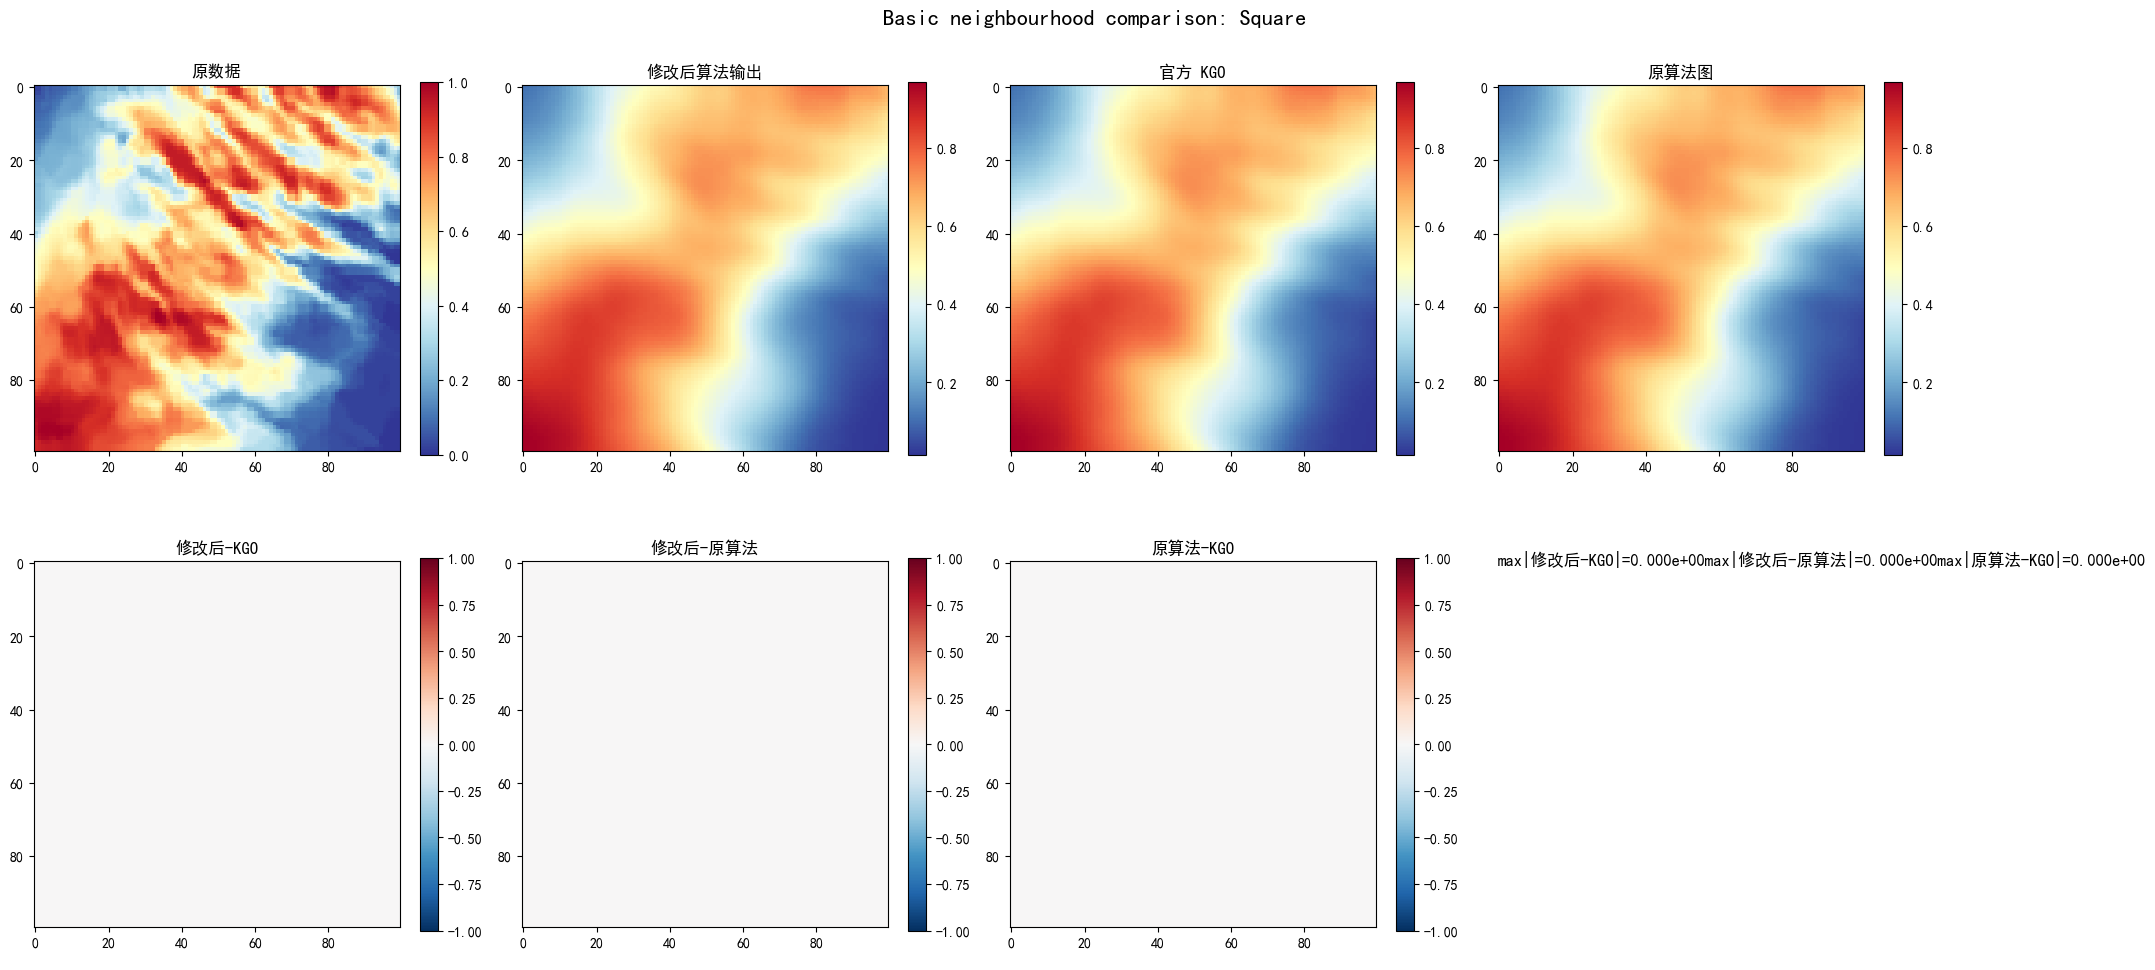

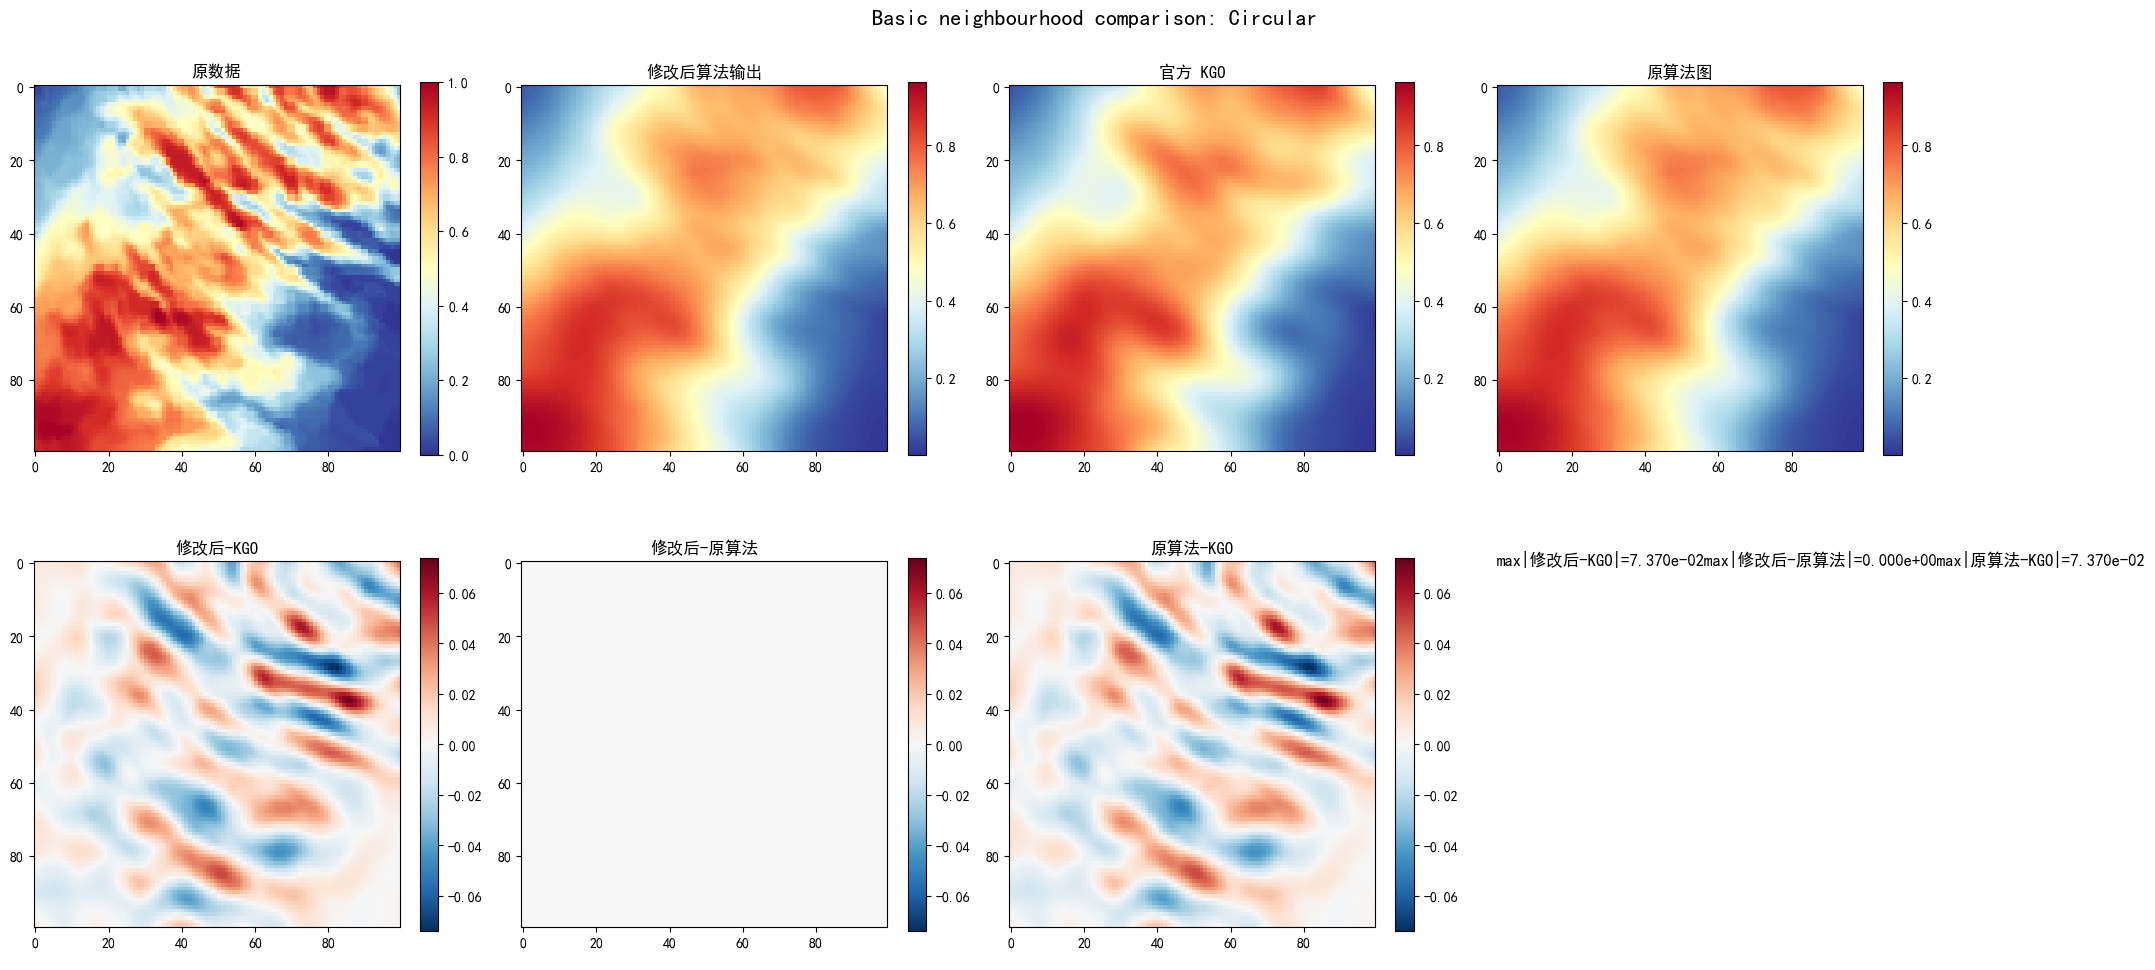

In [7]:
basic_kgo_square = load_primary(basic_dir / "kgo_square.nc")
basic_kgo_circular = load_primary(basic_dir / "kgo_circular.nc")
basic_original_square = load_primary(basic_dir / "original_square.nc")
basic_original_circular = load_primary(basic_dir / "original_circular.nc")

member_index = 0
plot_basic(
    "Basic neighbourhood comparison: Square",
    to_plot_2d(basic_input, member_index),
    to_plot_2d(basic_square, member_index),
    to_plot_2d(basic_kgo_square, member_index),
    to_plot_2d(basic_original_square, member_index),
)
plot_basic(
    "Basic neighbourhood comparison: Circular",
    to_plot_2d(basic_input, member_index),
    to_plot_2d(basic_circular, member_index),
    to_plot_2d(basic_kgo_circular, member_index),
    to_plot_2d(basic_original_circular, member_index),
)


## 5. 掩码处理对比

外部掩码中 `1` 表示参与计算，`0` 表示不参与计算。内部掩码样例使用 masked array 输入，迁移算法会把输入自身 mask 合并进邻域有效点统计。


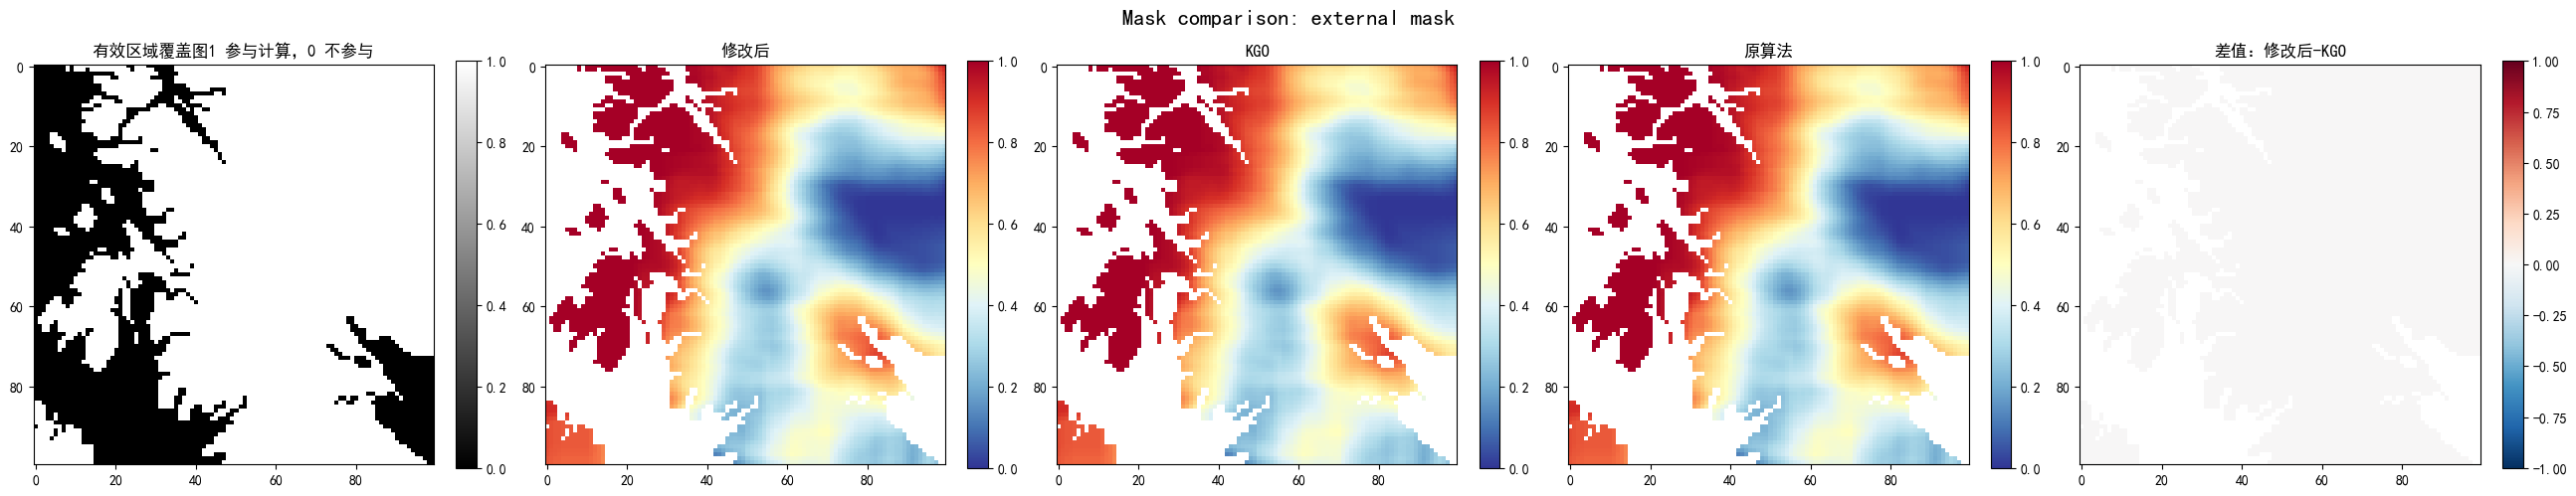

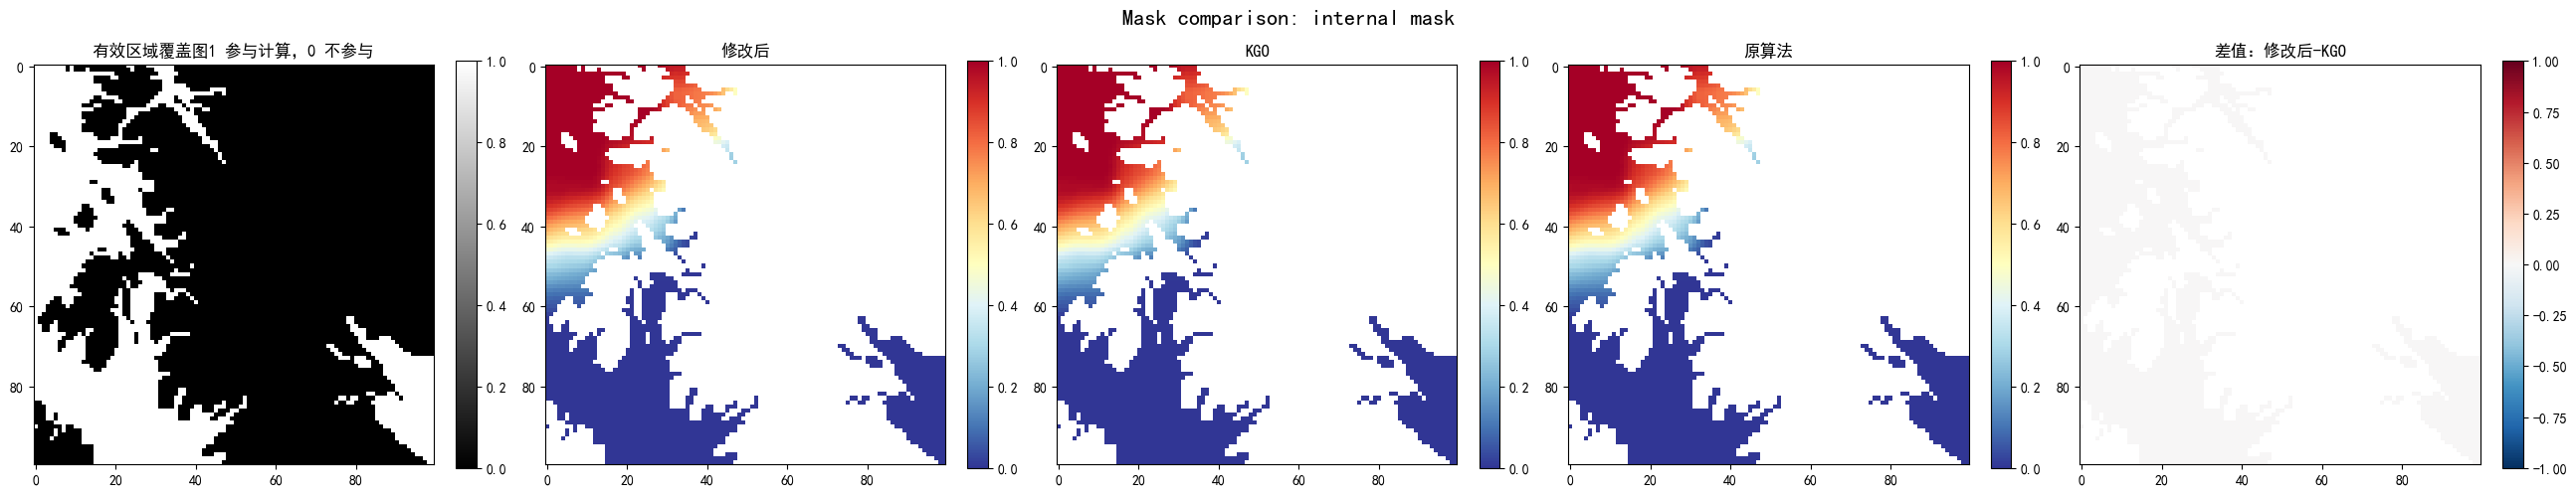

In [8]:

mask_dir = TEST_DATA_DIR / "mask"
mask_input = load_primary(mask_dir / "input.nc")
mask_external = load_primary(mask_dir / "mask.nc")

mask_modified_external = ensure_dataarray(
    NeighbourhoodProcessing("square", RADIUS_METRES).process(mask_input, mask=mask_external),
    mask_input,
)

external_valid_cover = to_plot_2d(mask_external, member_index=0) == 1
external_modified_plot = np.ma.masked_where(~external_valid_cover, to_plot_2d(mask_modified_external, 0))
external_kgo_plot = np.ma.masked_where(
    ~external_valid_cover,
    to_plot_2d(load_primary(mask_dir / "kgo_external_masked.nc", mask_and_scale=False), 0),
)
external_original_plot = np.ma.masked_where(
    ~external_valid_cover,
    to_plot_2d(load_primary(mask_dir / "original_external_masked.nc", mask_and_scale=False), 0),
)

plot_mask(
    "Mask comparison: external mask",
    external_valid_cover,
    external_modified_plot,
    external_kgo_plot,
    external_original_plot,
)

masked_input_da = load_primary(mask_dir / "input_masked.nc", mask_and_scale=False)
masked_input = masked_values(to_plot_2d(masked_input_da, 0))
masked_modified = NeighbourhoodProcessing("square", RADIUS_METRES).process(
    masked_input,
    grid_spacing=spacing_meters(masked_input_da),
)

plot_mask(
    "Mask comparison: internal mask",
    ~np.ma.getmaskarray(masked_input),
    masked_modified,
    masked_values(to_plot_2d(load_primary(mask_dir / "kgo_masked.nc", mask_and_scale=False), 0)),
    masked_values(to_plot_2d(load_primary(mask_dir / "original_masked.nc", mask_and_scale=False), 0)),
)


## 6. 百分位数对比

如果输入是numpy数组，则百分位迁移算法输出将输出首轴固定为 `percentile`；若输入是meteva_base网格数据， `percentile`维度与输入数据的`member`维度联合后映射到新的 `member` 维。

In [9]:
pct_dir = TEST_DATA_DIR / "percentile"
pct_input = load_primary(pct_dir / "input_circular_percentile.nc")
pct_kgo = load_primary(pct_dir / "kgo_circular_percentile.nc")
pct_original = load_primary(pct_dir / "original_circular_percentile.nc")

#调用邻域处理算法生成百分位数输出
pct_modified = GeneratePercentilesFromANeighbourhood(
    RADIUS_METRES,
    percentiles=PERCENTILES,
).process(pct_input)

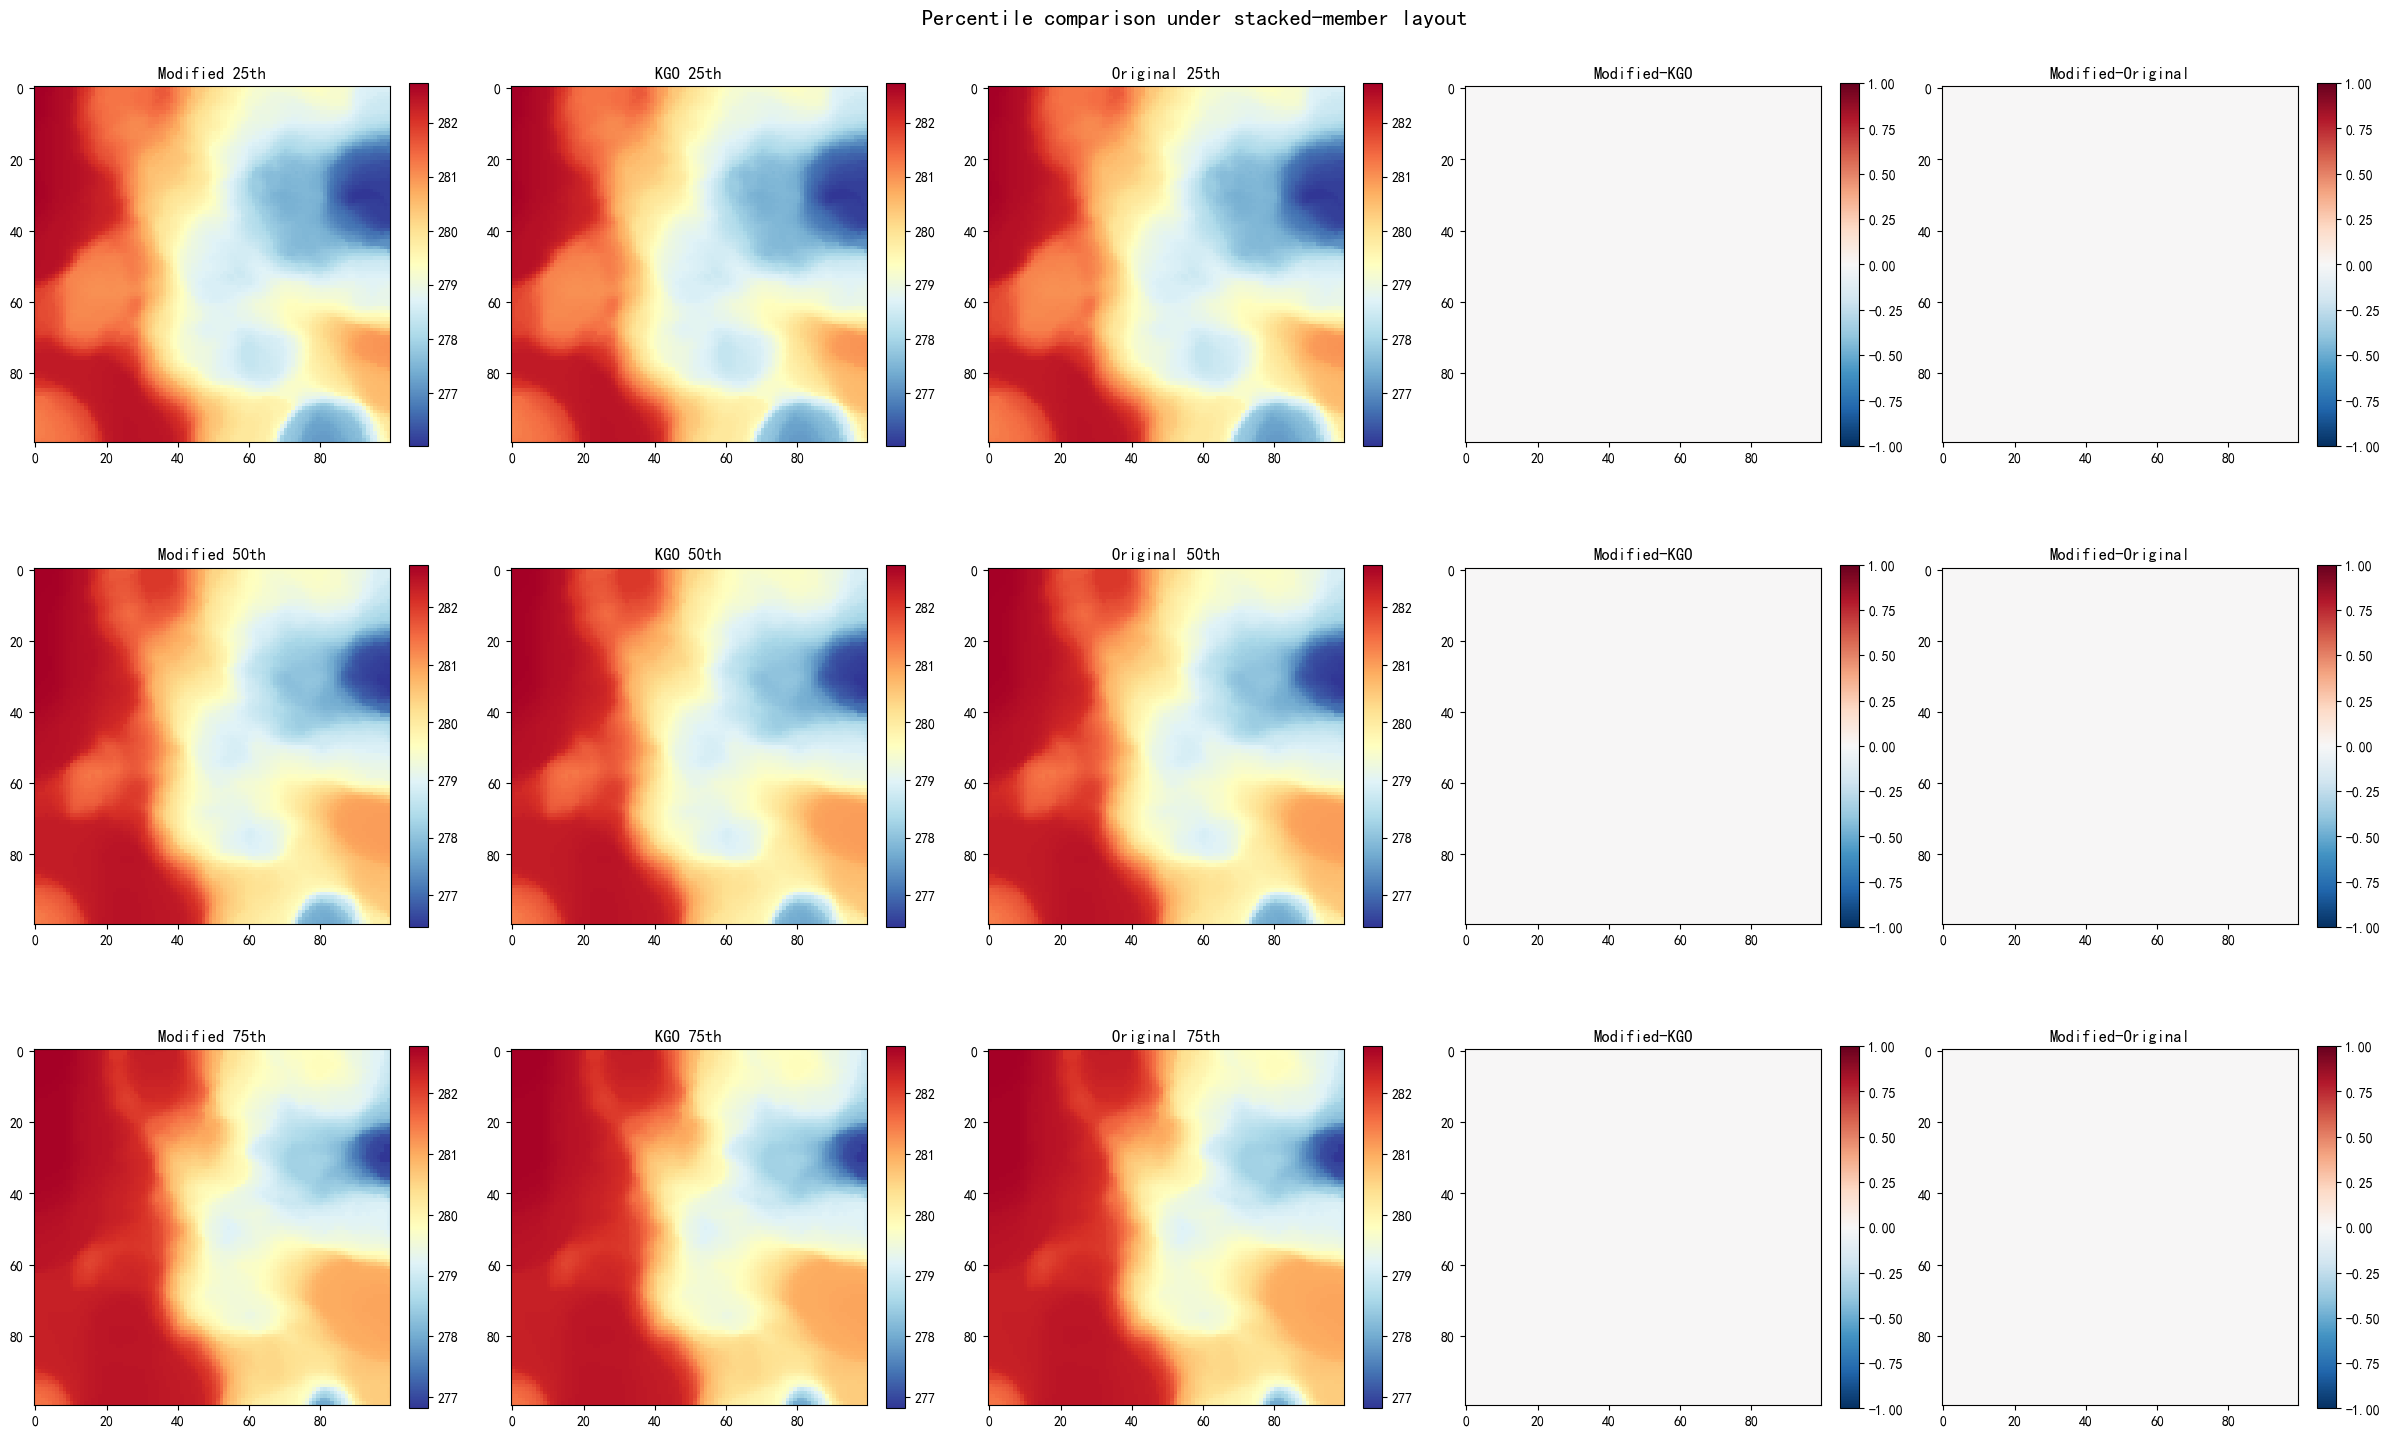

In [10]:
# KGO / original may use stacked member encoding: stack(member, percentile) -> member
fig, axes = plt.subplots(len(PERCENTILES), 5, figsize=(24, 5 * len(PERCENTILES)), squeeze=False)

for row, pct in enumerate(PERCENTILES):
    m_idx = pick_member_by_percentile(pct_modified, pct, prefer_realization_index=0)
    k_idx = pick_member_by_percentile(pct_kgo, pct, prefer_realization_index=0)
    o_idx = pick_member_by_percentile(pct_original, pct, prefer_realization_index=0)

    m = to_plot_2d(pct_modified, m_idx)
    k = to_plot_2d(pct_kgo, k_idx)
    o = to_plot_2d(pct_original, o_idx)

    vmin, vmax = common_limits(m, k, o)
    diff_mk, diff_mo = m - k, m - o
    norm = diff_norm(diff_mk, diff_mo)

    value_panels = [
        (axes[row, 0], m, f"Modified {pct:.0f}th"),
        (axes[row, 1], k, f"KGO {pct:.0f}th"),
        (axes[row, 2], o, f"Original {pct:.0f}th"),
    ]
    for ax, data, name in value_panels:
        im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)

    diff_panels = [(axes[row, 3], diff_mk, "Modified-KGO"), (axes[row, 4], diff_mo, "Modified-Original")]
    for ax, data, name in diff_panels:
        im = ax.imshow(data, cmap="RdBu_r", norm=norm, interpolation="nearest")
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("Percentile comparison under stacked-member layout", fontsize=16)
fig.tight_layout()
plt.show()


In [11]:

print('pct_modified dims:', getattr(pct_modified, 'dims', None))
if isinstance(pct_modified, xr.DataArray):
    print('pct_modified coords:', [k for k in pct_modified.coords if k.startswith('member')])


pct_modified dims: ('member', 'level', 'time', 'dtime', 'lat', 'lon')
pct_modified coords: ['member', 'member_input_member', 'member_percentile']


In [12]:
print(pct_modified)

<xarray.DataArray 'air_temperature' (member: 12, level: 1, time: 1, dtime: 1,
                                     lat: 100, lon: 100)> Size: 480kB
array([[[[[[282.72955, 282.71686, 282.70816, ..., 278.65   ,
            278.65   , 278.65   ],
           [282.71967, 282.7116 , 282.70474, ..., 278.6311 ,
            278.6311 , 278.6267 ],
           [282.71686, 282.70816, 282.70346, ..., 278.5644 ,
            278.5644 , 278.5644 ],
           ...,
           [281.18338, 281.1882 , 281.20508, ..., 279.45123,
            279.58145, 279.79102],
           [281.19818, 281.19818, 281.21866, ..., 279.2789 ,
            279.58145, 279.79102],
           [281.22113, 281.22113, 281.242  , ..., 279.2789 ,
            279.45123, 279.61548]]]]],




       [[[[[282.74323, 282.74323, 282.74323, ..., 278.8587 ,
            278.8587 , 278.8587 ],
           [282.74323, 282.74323, 282.74323, ..., 278.8587 ,
...
           [281.419  , 281.419  , 281.4522 , ..., 279.8724 ,
            279.8724 , 279.957

## 7. CLI 应用示例

示例脚本：`nbhood/cli/ens_nbhood.py`

方形邻域概率（脚本内置默认示例）：

```powershell
python -m nbhood.cli.ens_nbhood
```

百分位输出可在 Notebook 或脚本中调用 `process()`：

```python
from nbhood.cli.ens_nbhood import process

#数据存放路径
base = "./nbhood/test_data/official_test_nbhood/normalized_meb6d/percentile"
process(
    input_data_path=f"{base}/input_circular_percentile.nc",
    neighbourhood_output="percentiles",
    radii=[20000.0],
    percentiles=[25.0, 50.0, 75.0],
    output_path=f"{base}/cli_nbhood_percentiles.nc",
)
```


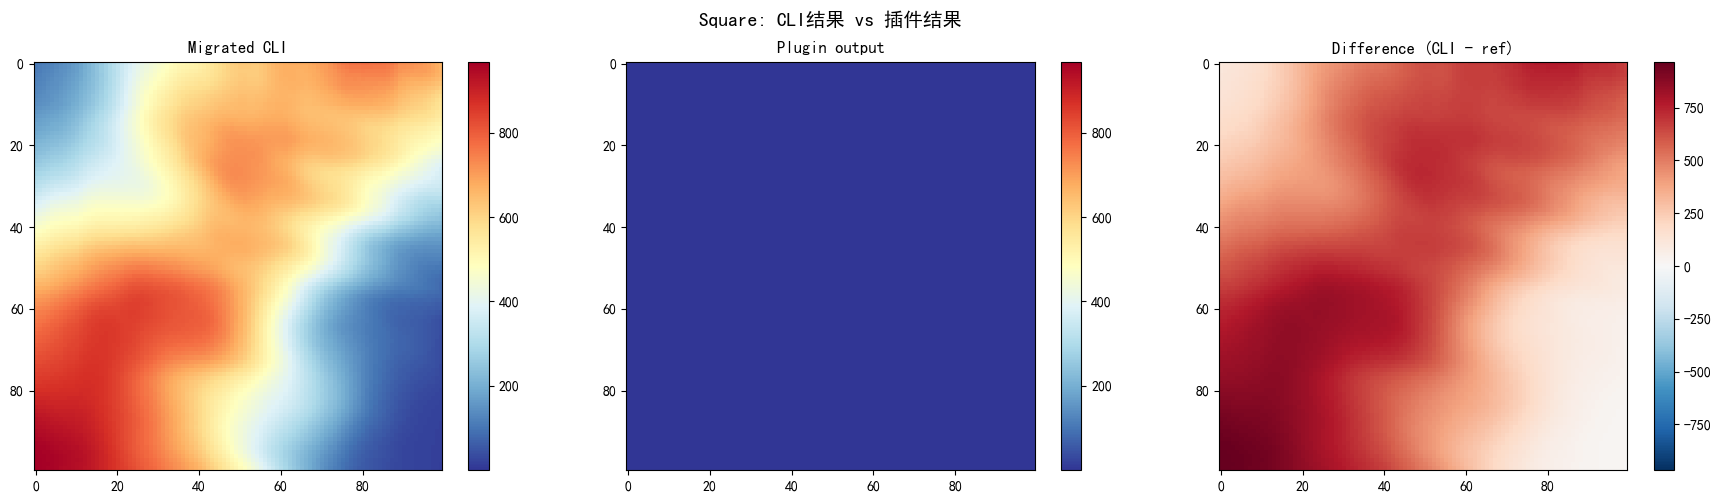

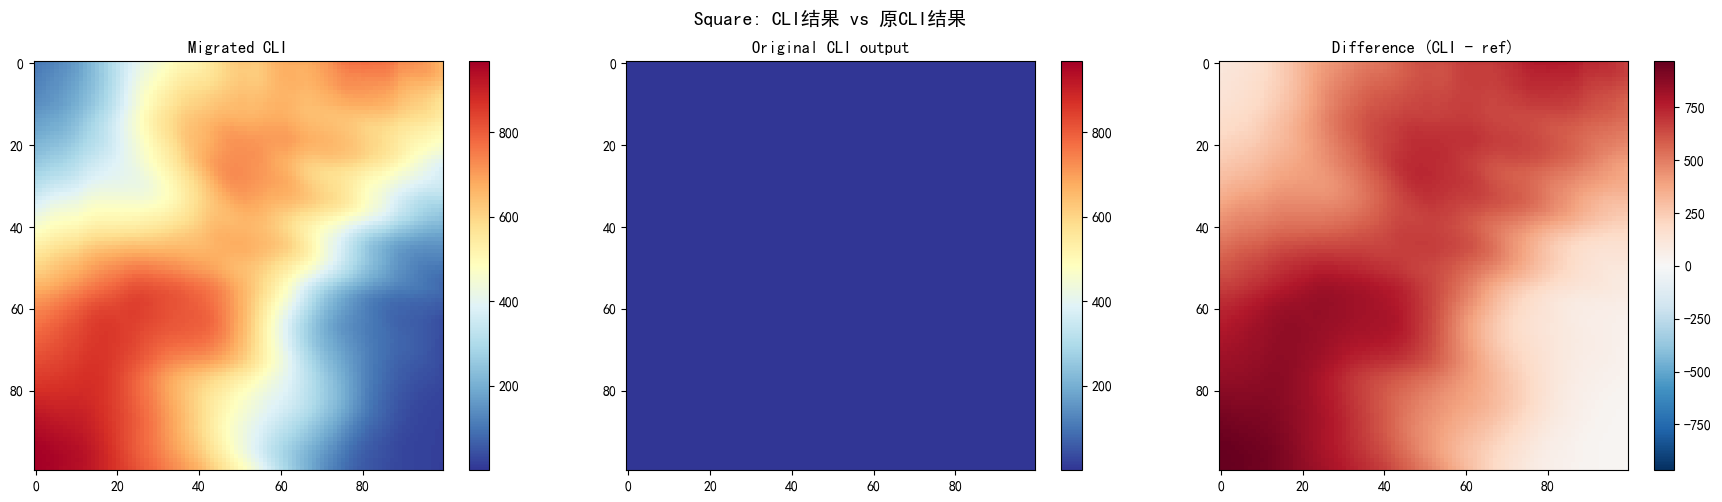

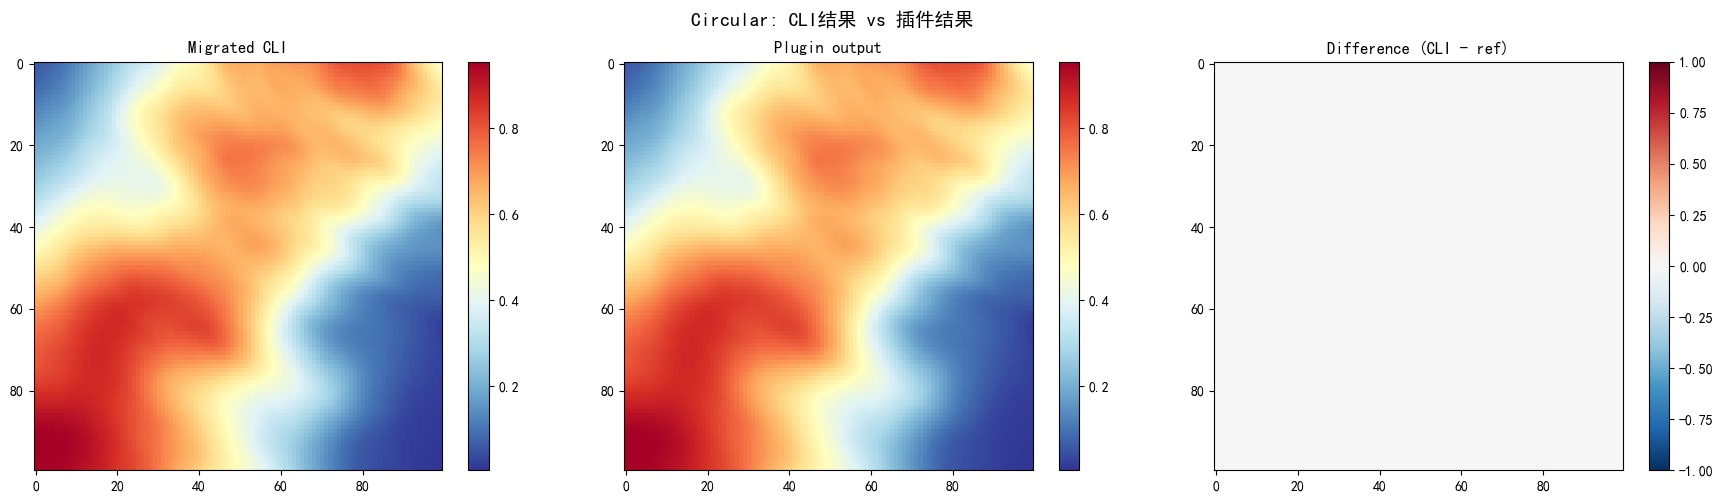

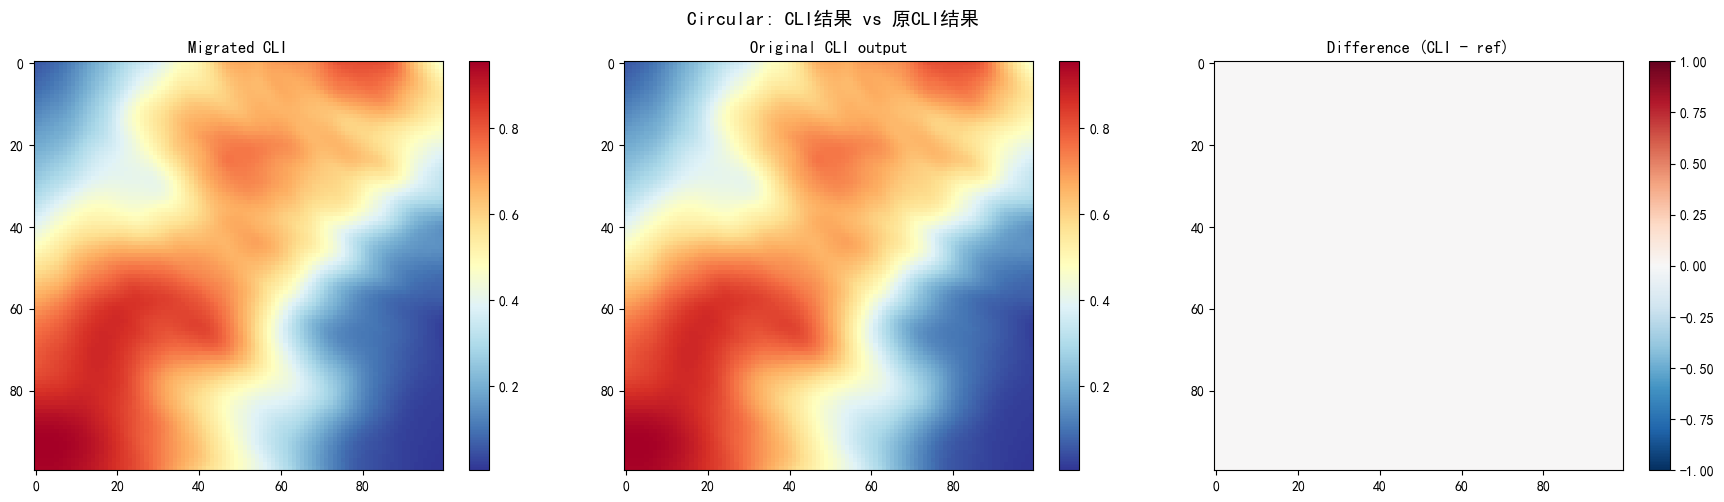

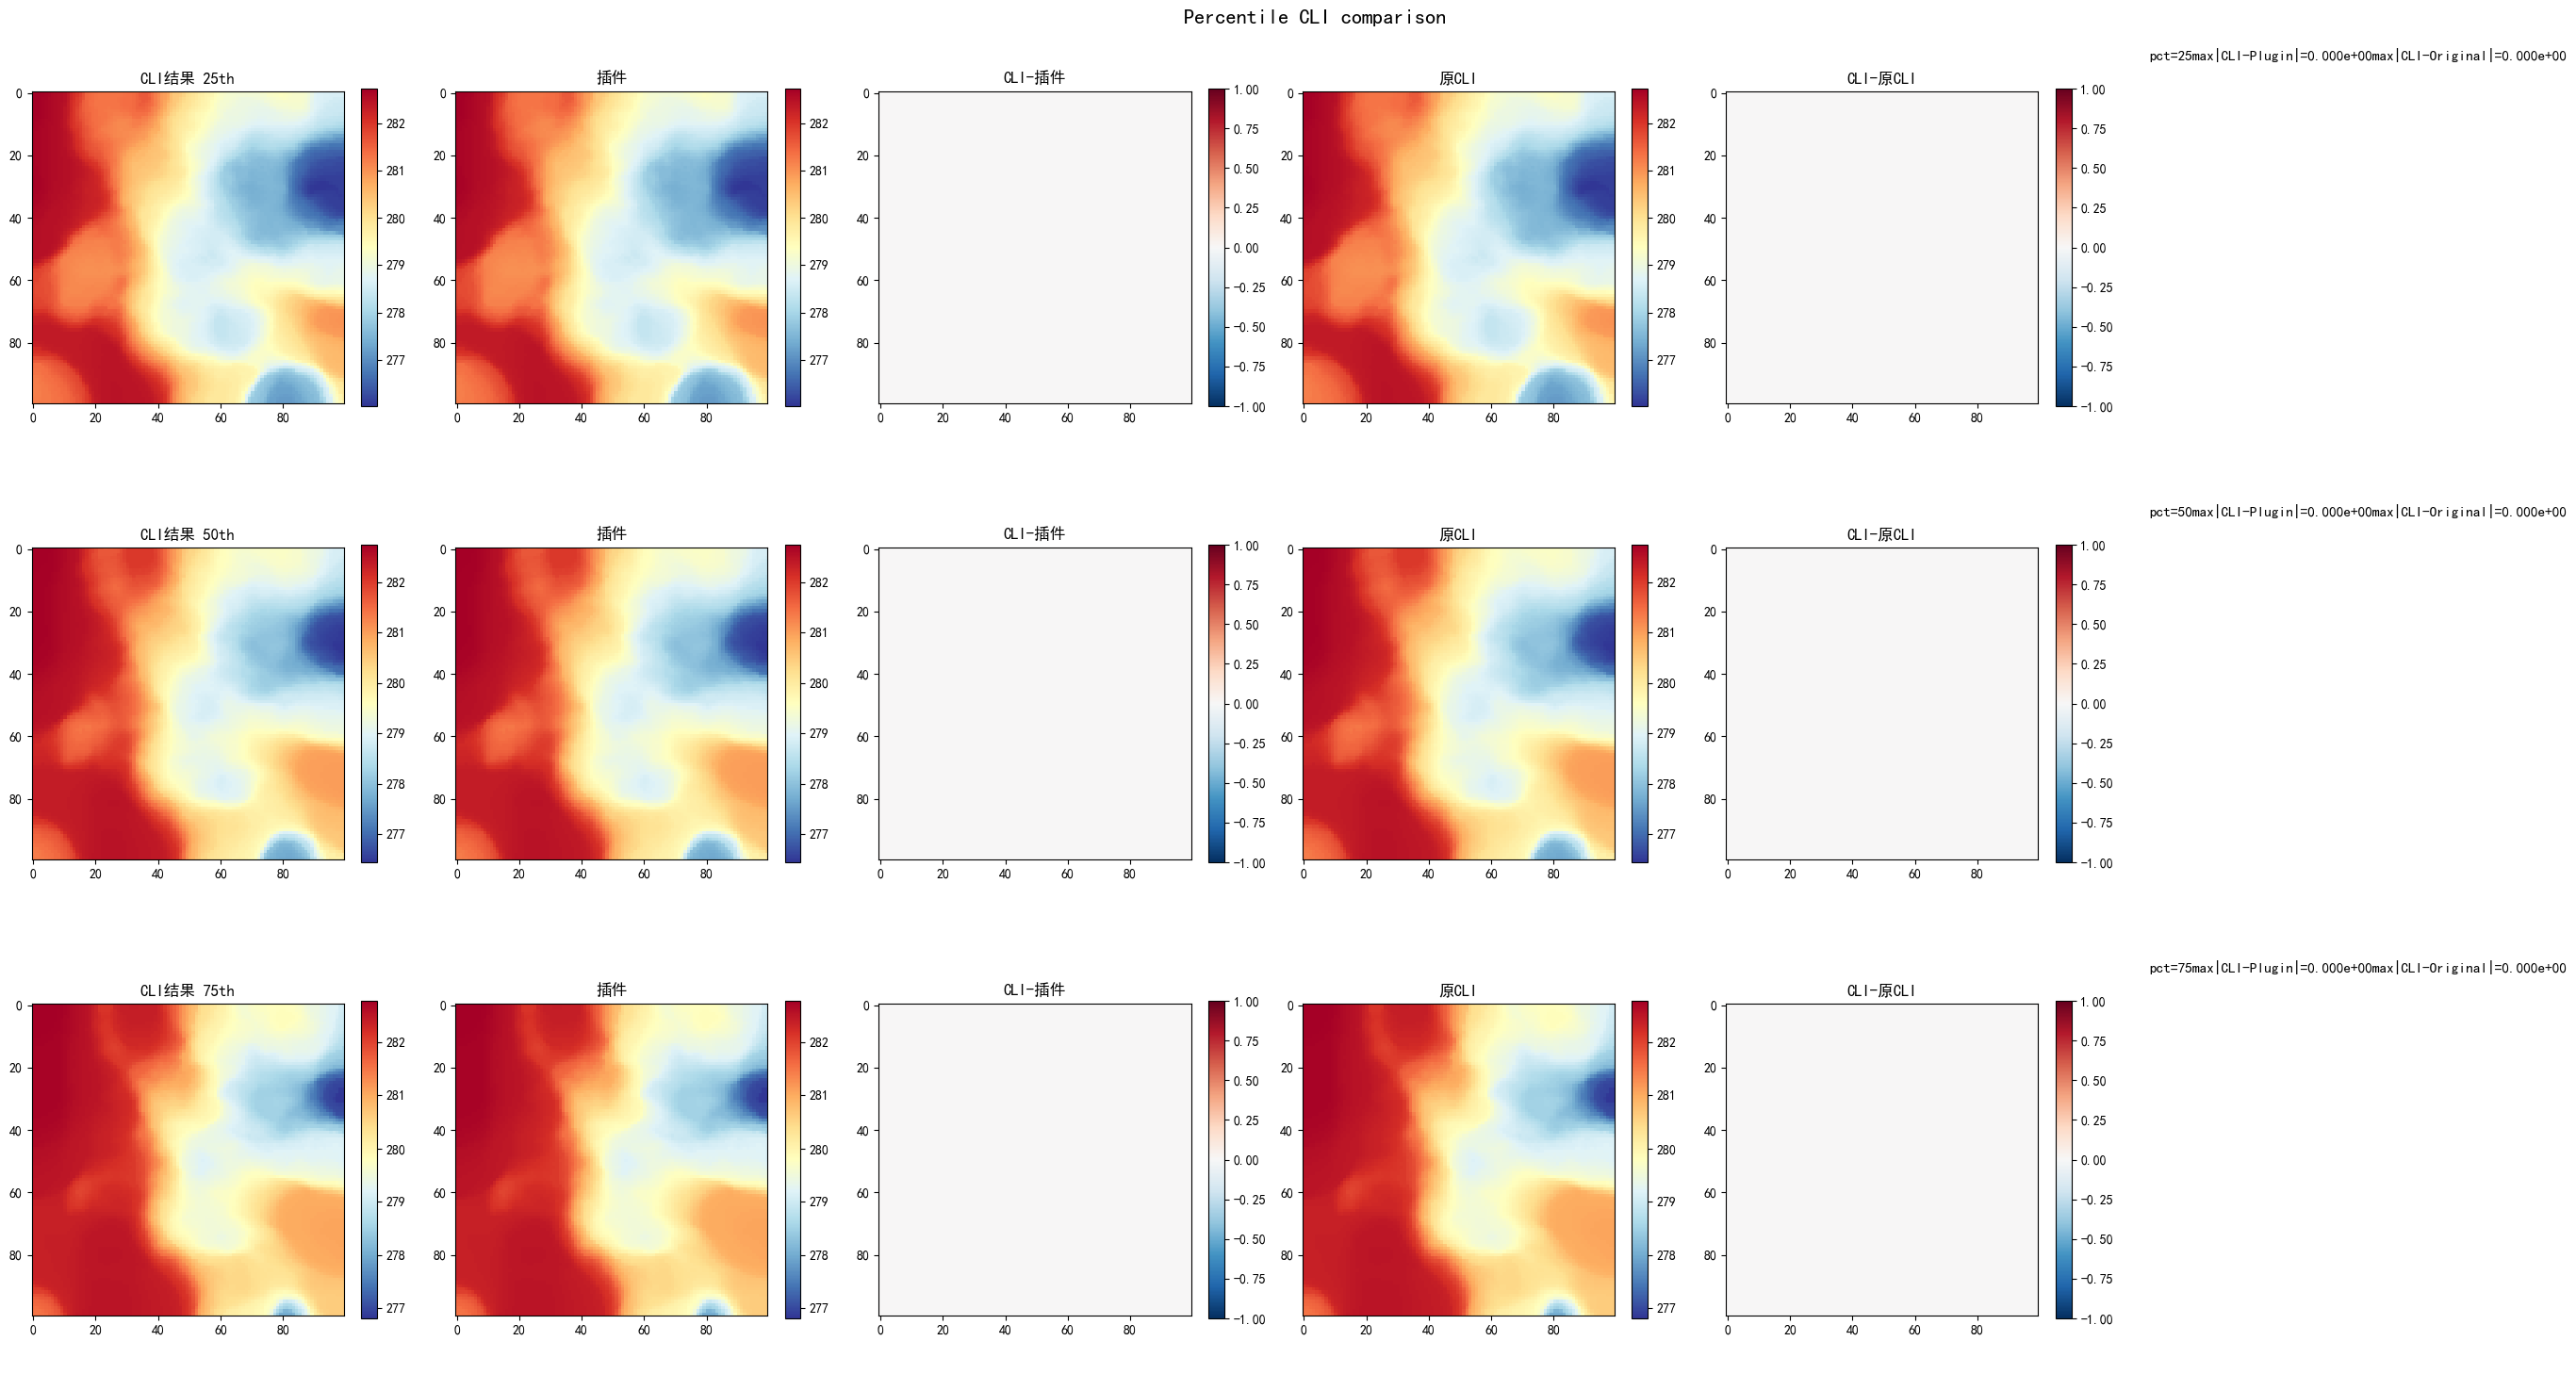

In [13]:
# CLI output readback and comparison

basic_dir = TEST_DATA_DIR / "basic"
pct_dir = TEST_DATA_DIR / "percentile"

cli_nb_square_path = basic_dir / "cli_nbhood_square_result.nc"
cli_nb_circular_path = basic_dir / "cli_nbhood_circular_result.nc"
cli_org_square_path = basic_dir / "cli_square_result.nc"
cli_org_circular_path = basic_dir / "cli_circular_result.nc"

cli_nb_pct_path = pct_dir / "cli_nbhood_percentiles.nc"
cli_org_pct_path = pct_dir / "cli_circular_percentile_result.nc"


def _ensure_plugin_basic_results():
    global basic_square, basic_circular
    if "basic_square" not in globals() or "basic_circular" not in globals():
        basic_input_local = load_primary(basic_dir / "input.nc")
        basic_square = ensure_dataarray(
            NeighbourhoodProcessing("square", RADIUS_METRES).process(basic_input_local),
            basic_input_local,
        )
        basic_circular = ensure_dataarray(
            NeighbourhoodProcessing("circular", RADIUS_METRES).process(basic_input_local),
            basic_input_local,
        )


def _ensure_plugin_percentile_result():
    global pct_modified
    if "pct_modified" not in globals():
        pct_input_local = load_primary(pct_dir / "input_circular_percentile.nc")
        pct_modified = GeneratePercentilesFromANeighbourhood(
            RADIUS_METRES,
            percentiles=PERCENTILES,
        ).process(pct_input_local)


def plot_cli_vs_ref(title, cli_da, ref_da, ref_name):
    cli_2d = to_plot_2d(cli_da, 0)
    ref_2d = to_plot_2d(ref_da, 0)

    vmin, vmax = common_limits(cli_2d, ref_2d)
    diff = cli_2d - ref_2d
    norm = diff_norm(diff)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    im0 = axes[0].imshow(cli_2d, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
    axes[0].set_title("Migrated CLI")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(ref_2d, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
    axes[1].set_title(ref_name)
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(diff, cmap="RdBu_r", norm=norm, interpolation="nearest")
    axes[2].set_title("Difference (CLI - ref)")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


# ---- Basic: square / circular ----
missing_basic = [
    path for path in [cli_nb_square_path, cli_nb_circular_path, cli_org_square_path, cli_org_circular_path]
    if not path.exists()
]
if missing_basic:
    print("Missing basic CLI files:")
    for path in missing_basic:
        print(" -", path)
else:
    _ensure_plugin_basic_results()

    cli_nb_square = load_primary(cli_nb_square_path)
    cli_nb_circular = load_primary(cli_nb_circular_path)
    cli_org_square = load_primary(cli_org_square_path)
    cli_org_circular = load_primary(cli_org_circular_path)

    plot_cli_vs_ref(
        "Square: CLI结果 vs 插件结果",
        cli_nb_square,
        basic_square,
        "Plugin output",
    )
    plot_cli_vs_ref(
        "Square: CLI结果 vs 原CLI结果",
        cli_nb_square,
        cli_org_square,
        "Original CLI output",
    )

    plot_cli_vs_ref(
        "Circular: CLI结果 vs 插件结果",
        cli_nb_circular,
        basic_circular,
        "Plugin output",
    )
    plot_cli_vs_ref(
        "Circular: CLI结果 vs 原CLI结果",
        cli_nb_circular,
        cli_org_circular,
        "Original CLI output",
    )


# ---- Percentile: migrated CLI vs plugin / original CLI ----
missing_pct = [path for path in [cli_nb_pct_path, cli_org_pct_path] if not path.exists()]
if missing_pct:
    print("Missing percentile CLI files:")
    for path in missing_pct:
        print(" -", path)
else:
    _ensure_plugin_percentile_result()

    cli_nb_pct = load_primary(cli_nb_pct_path)
    cli_org_pct = load_primary(cli_org_pct_path)

    fig, axes = plt.subplots(len(PERCENTILES), 6, figsize=(28, 5 * len(PERCENTILES)), squeeze=False)
    for row, pct in enumerate(PERCENTILES):
        c_idx = pick_member_by_percentile(cli_nb_pct, pct, prefer_realization_index=0)
        p_idx = pick_member_by_percentile(pct_modified, pct, prefer_realization_index=0)
        o_idx = pick_member_by_percentile(cli_org_pct, pct, prefer_realization_index=0)

        c = to_plot_2d(cli_nb_pct, c_idx)
        p = to_plot_2d(pct_modified, p_idx)
        o = to_plot_2d(cli_org_pct, o_idx)

        vmin, vmax = common_limits(c, p, o)
        diff_cp = c - p
        diff_co = c - o
        norm = diff_norm(diff_cp, diff_co)

        panels = [
            (axes[row, 0], c, f"CLI结果 {pct:.0f}th", "value"),
            (axes[row, 1], p, "插件", "value"),
            (axes[row, 2], diff_cp, "CLI-插件", "diff"),
            (axes[row, 3], o, "原CLI", "value"),
            (axes[row, 4], diff_co, "CLI-原CLI", "diff"),
        ]
        for ax, data, title, kind in panels:
            if kind == "value":
                im = ax.imshow(data, cmap="RdYlBu_r", vmin=vmin, vmax=vmax, interpolation="nearest")
            else:
                im = ax.imshow(data, cmap="RdBu_r", norm=norm, interpolation="nearest")
            ax.set_title(title)
            plt.colorbar(im, ax=ax, fraction=0.046)

        axes[row, 5].axis("off")
        axes[row, 5].text(
            0,
            0.95,
            f"pct={pct:.0f}max|CLI-Plugin|={np.nanmax(np.abs(diff_cp)):.3e}max|CLI-Original|={np.nanmax(np.abs(diff_co)):.3e}",
            va="top",
            fontsize=11,
        )

    fig.suptitle("Percentile CLI comparison", fontsize=16)
    fig.tight_layout()
    plt.show()


## 8. 数据展示

本节对 notebook 中已经读取或生成的关键输入场与插件结果做单图展示。每幅图只展示一个输入或一个插件结果，不再重复绘制 KGO / 原算法结果。

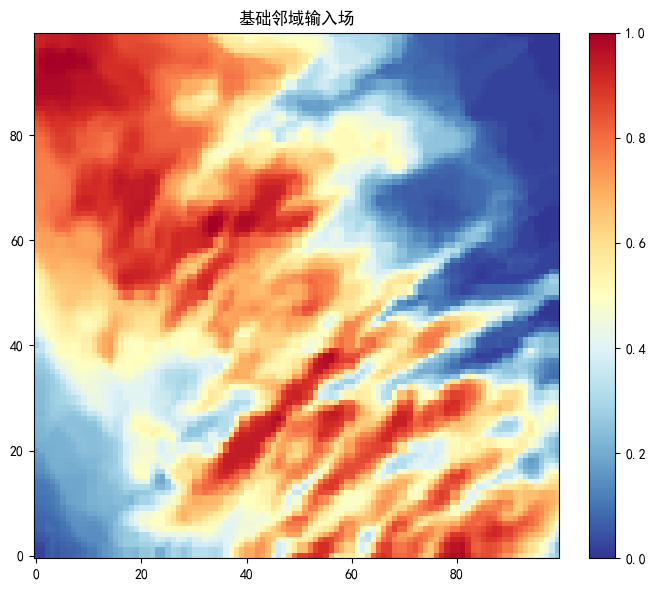

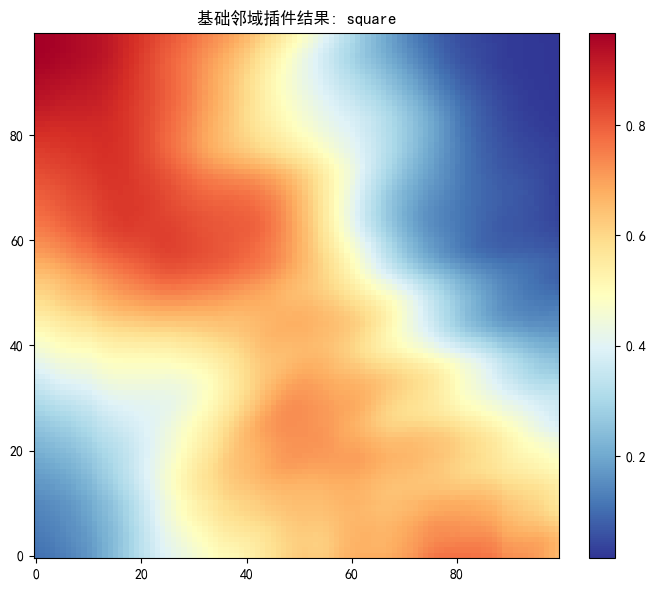

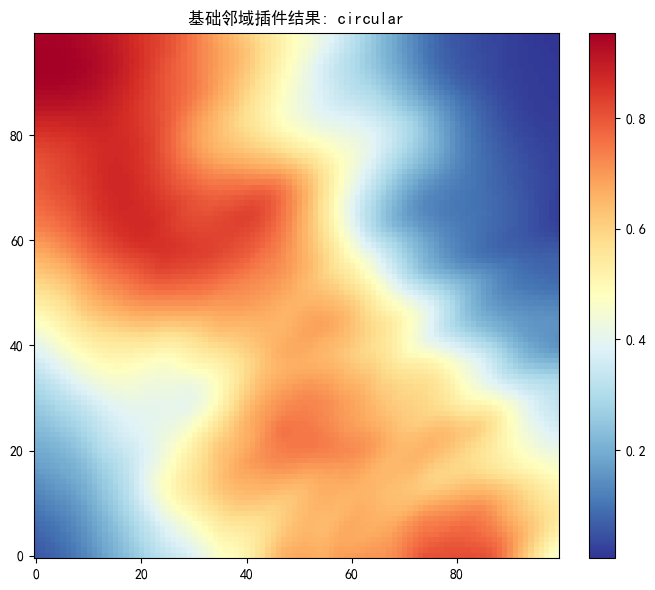

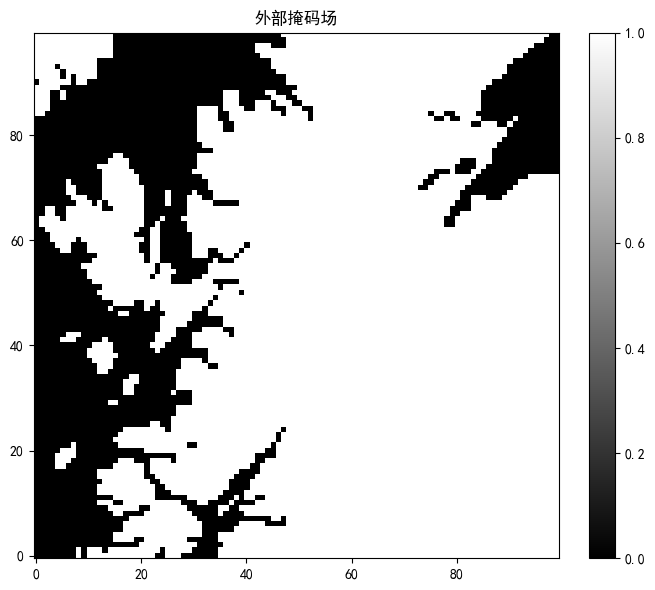

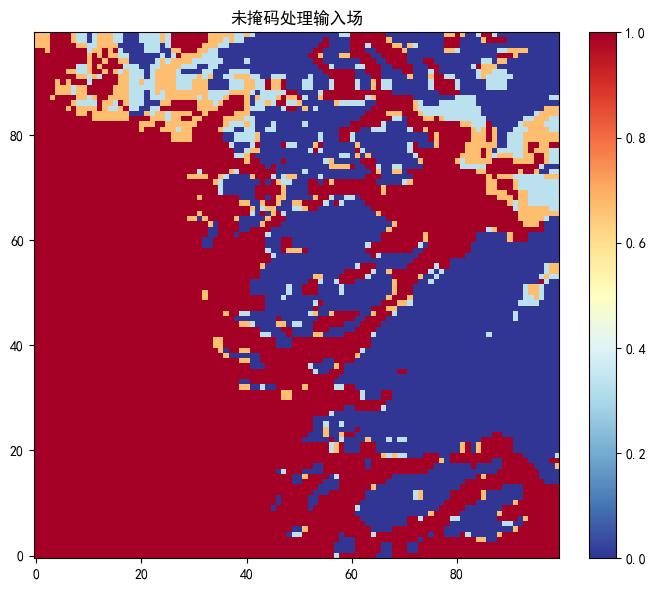

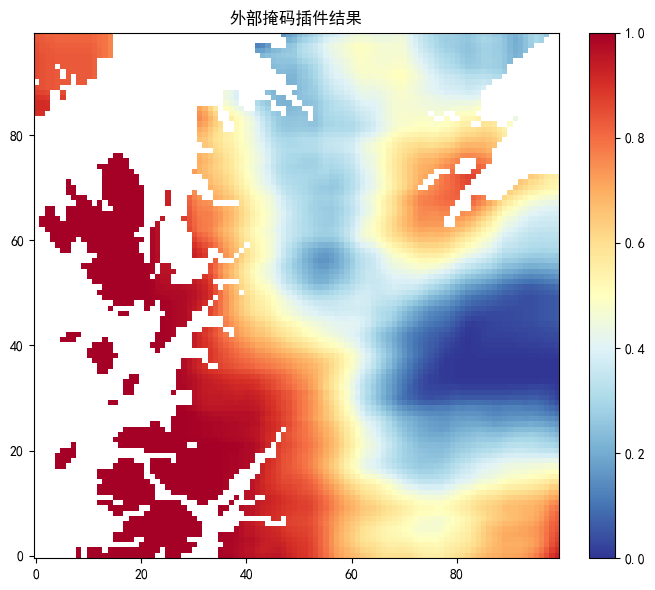

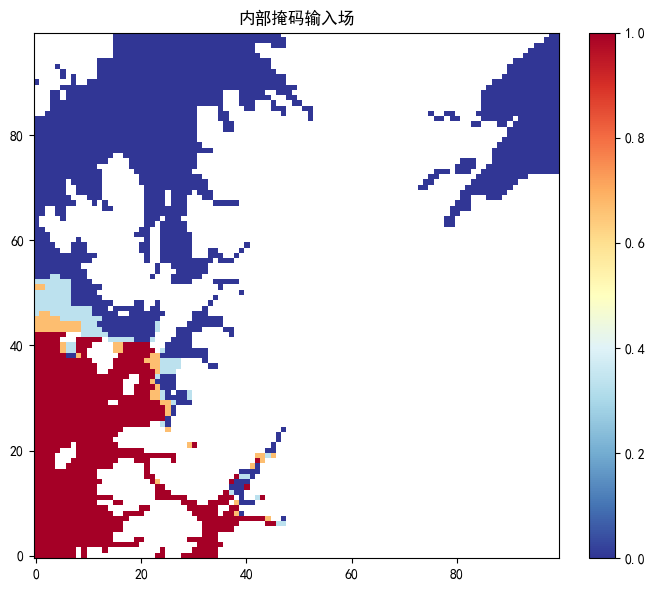

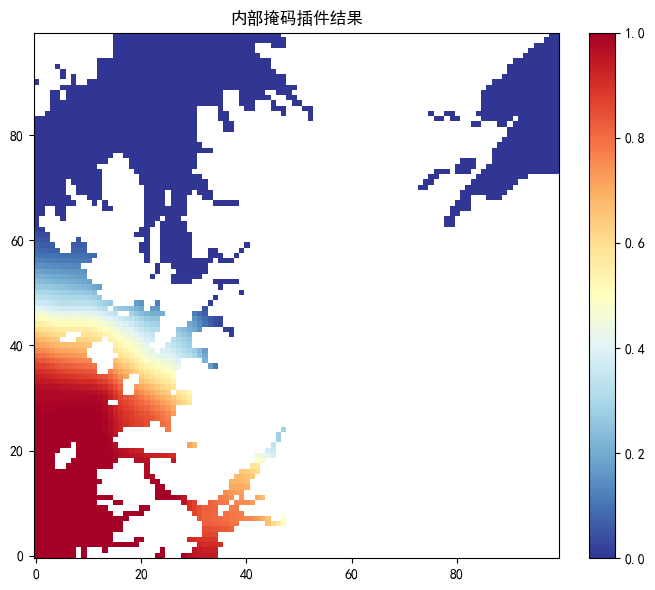

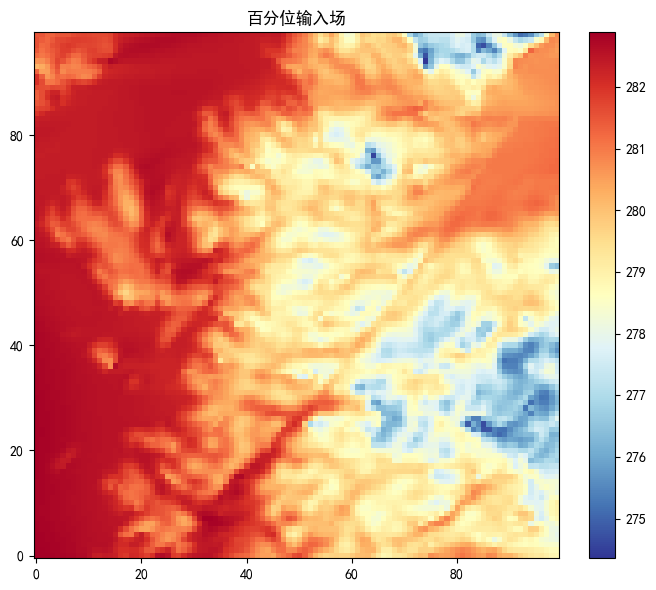

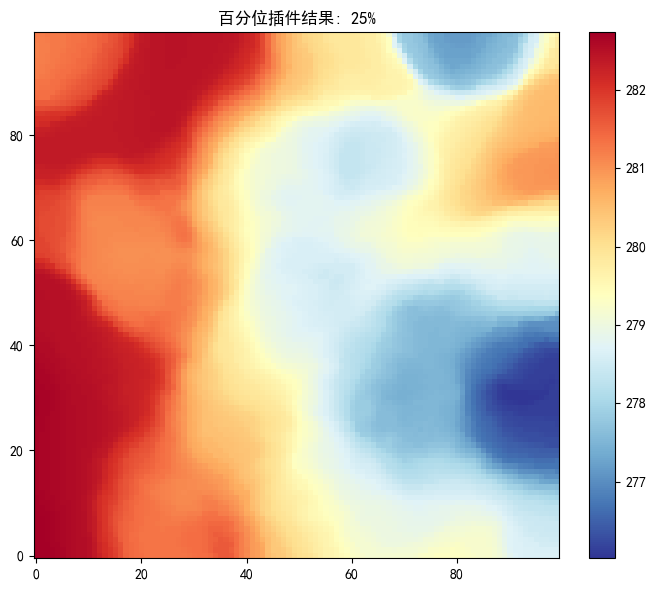

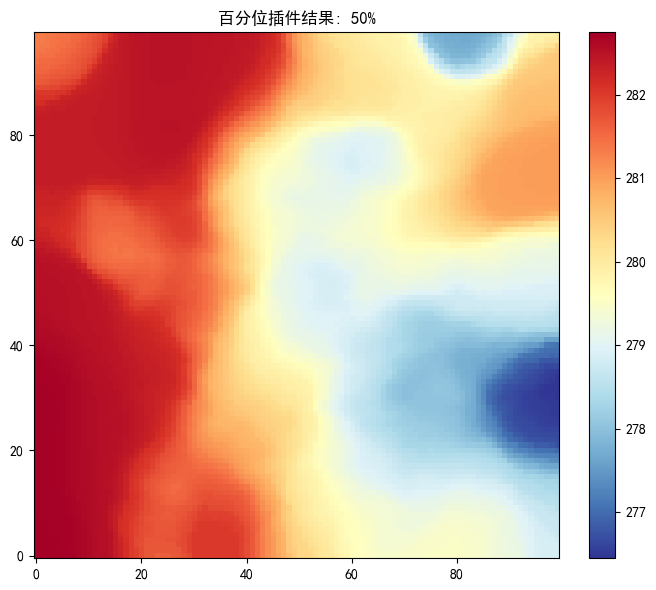

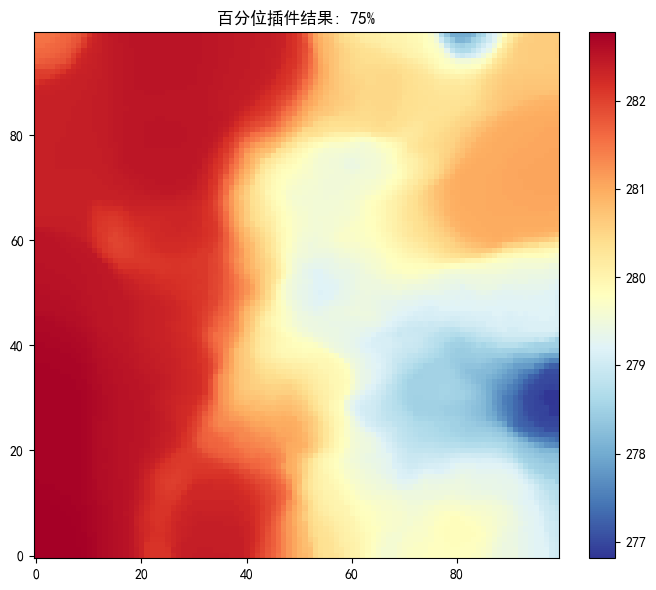

In [14]:
def plot_single_field(title, data, cmap="RdYlBu_r"):
    """单独绘制一个二维场。"""
    values = np.ma.asarray(data)
    plt.figure(figsize=(8, 6))
    plt.imshow(values, origin="lower", cmap=cmap, interpolation="nearest")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# 尽量复用前文变量；如果当前会话未运行到对应单元，则按需补载。
basic_dir = TEST_DATA_DIR / "basic"
mask_dir = TEST_DATA_DIR / "mask"
pct_dir = TEST_DATA_DIR / "percentile"

if "basic_input" not in globals():
    basic_input = load_primary(basic_dir / "input.nc")
if "basic_square" not in globals():
    basic_square = ensure_dataarray(
        NeighbourhoodProcessing("square", RADIUS_METRES).process(basic_input),
        basic_input,
    )
if "basic_circular" not in globals():
    basic_circular = ensure_dataarray(
        NeighbourhoodProcessing("circular", RADIUS_METRES).process(basic_input),
        basic_input,
    )

if "mask_input" not in globals():
    mask_input = load_primary(mask_dir / "input.nc")
if "mask_external" not in globals():
    mask_external = load_primary(mask_dir / "mask.nc")
if "mask_modified_external" not in globals():
    mask_modified_external = ensure_dataarray(
        NeighbourhoodProcessing("square", RADIUS_METRES).process(mask_input, mask=mask_external),
        mask_input,
    )
if "masked_input_da" not in globals():
    masked_input_da = load_primary(mask_dir / "input_masked.nc", mask_and_scale=False)
if "masked_input" not in globals():
    masked_input = masked_values(to_plot_2d(masked_input_da, 0))
if "masked_modified" not in globals():
    masked_modified = NeighbourhoodProcessing("square", RADIUS_METRES).process(
        masked_input,
        grid_spacing=spacing_meters(masked_input_da),
    )

if "pct_input" not in globals():
    pct_input = load_primary(pct_dir / "input_circular_percentile.nc")
if "pct_modified" not in globals():
    pct_modified = NeighbourhoodProcessing(
        "circular",
        RADIUS_METRES,
        percentiles=PERCENTILES,
    ).process(pct_input)

plot_single_field("基础邻域输入场", to_plot_2d(basic_input, 0))
plot_single_field("基础邻域插件结果: square", to_plot_2d(basic_square, 0))
plot_single_field("基础邻域插件结果: circular", to_plot_2d(basic_circular, 0))

plot_single_field("外部掩码场", to_plot_2d(mask_external, 0), cmap="gray")
plot_single_field("未掩码处理输入场", to_plot_2d(mask_input, 0))
plot_single_field("外部掩码插件结果", to_plot_2d(mask_modified_external, 0))

plot_single_field("内部掩码输入场", masked_input)
plot_single_field("内部掩码插件结果", masked_modified)

plot_single_field("百分位输入场", to_plot_2d(pct_input, 0))
for pct in PERCENTILES:
    pct_member_index = pick_member_by_percentile(pct_modified, pct, prefer_realization_index=0)
    plot_single_field(
        f"百分位插件结果: {pct:g}%",
        to_plot_2d(pct_modified, pct_member_index),
    )